# 2D Kolmogorov Wavefront Tomography

This notebook is the second teaching-oriented stage of the WFS project. It extends the simple two-layer model into a **2D atmospheric wavefront-sensing and tomography pipeline**.

## Main pipeline

**2D point sources → Kolmogorov OPD layers → ray tracing → physical lenslet images → source-wise pairwise NCC → relative tilt → coarse-to-fine tomography → 2D OPD → pupil PSF → Strehl ratio**

## Key updates from the first toy model

1. **1D → 2D geometry:** sources, lenslets, OPD, and slopes are now defined over both $x$ and $y$.
2. **Kolmogorov-like → physical Kolmogorov statistics:** the turbulence strength is tied to $r_0$, wavelength, and approximately $1$ arcsec seeing.
3. **Clean reference → self-reference:** the estimator no longer receives an aberration-free image.
4. **Gaussian spot → diffraction PSF:** circular microlens images are generated from a pupil model and sampled with a 2D CZT.
5. **Simple inversion → coarse-to-fine tomography:** the solver is designed to reduce layer cross-talk and layer swapping.
6. **1D OPD → 2D AO validation:** reconstructed slopes are converted to OPD maps and tested through pupil-plane propagation and Strehl ratio.

## Main technical difficulties

- A finite FFT grid undersamples very low spatial frequencies in a Kolmogorov phase screen.
- Pairwise image registration recovers only **relative** source-wise displacement, so a common-mode gauge remains unobservable.
- A very good forward fit does not guarantee that the two individual layers are separated correctly.
- Fine reconstruction grids improve spatial detail but can make the inverse problem more ill-conditioned.
- AO performance depends on the **effective residual OPD over the pupil**, not only on visual similarity between individual reconstructed layers.

## Scope

The hidden OPD layers are used only to generate synthetic observations and to evaluate the final reconstruction. They are not supplied to the NCC estimator or tomography solver.

Some helper-function names retain historical version tags such as `v252` to preserve reproducibility of the original implementation.


## 1. Imports

Numerical, plotting, signal-processing, CZT, and sparse least-squares tools used throughout the notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve, CZT
from scipy import sparse, ndimage
from scipy.sparse.linalg import lsqr

np.set_printoptions(precision=4, suppress=True)


## 2. 2D Geometry and Lenslet Array

The source plane, two hidden layer planes, microlens plane, and sensor plane are defined first. The microlenses form a 2D grid.

> **Key update:** the inverse problem is now genuinely two-dimensional. Each measurement can constrain both $dW/dx$ and $dW/dy$.


In [2]:
# Axial geometry.
z_source = 1.0
z_lenslet = 0.0
z_sensor = -0.25

f_ml = abs(z_sensor - z_lenslet)

# Two thin turbulent layers between source plane and lenslet plane.
z_layers = np.array([0.35, 0.70])


In [3]:
# 2D microlens array.
n_lenslets = 13
lenslet_pitch = 0.022
lenslet_radius = 0.007

lenslet_axis = (
    np.arange(n_lenslets) - (n_lenslets - 1) / 2
) * lenslet_pitch

lenslet_x_grid, lenslet_y_grid = np.meshgrid(
    lenslet_axis,
    lenslet_axis,
    indexing="xy",
)

lenslet_centers_xy = np.column_stack([
    lenslet_x_grid.ravel(),
    lenslet_y_grid.ravel(),
])

n_lenslet_total = len(lenslet_centers_xy)

aperture_radius = (
    np.max(np.sqrt(lenslet_centers_xy[:, 0]**2 + lenslet_centers_xy[:, 1]**2))
    + lenslet_pitch / 2
)


In [4]:
print(f"Lenslet grid: {n_lenslets} x {n_lenslets}")
print(f"Total lenslets: {n_lenslet_total}")
print(f"Aperture radius: {aperture_radius:.3f}")


Lenslet grid: 13 x 13
Total lenslets: 169
Aperture radius: 0.198


### 2.1 Stratified 2D Point Sources

The sources are randomly distributed using stratified sampling so that the field is covered more evenly than with unconstrained random sampling.

> **Why this matters:** different source positions create different ray footprints on the two hidden layers. This parallax is the information that allows tomography to distinguish one layer from another.


In [5]:
# Random source parameters.
n_sources_per_axis = 6
source_extent = 0.18
source_flux_range = (0.35, 1.00)
rng_source = np.random.default_rng(21)


In [6]:
def make_stratified_random_point_sources_2d(
    n_sources_per_axis,
    source_extent,
    flux_range,
    rng,
):
    """Generate random 2D source positions with roughly uniform field coverage."""
    cell_edges = np.linspace(
        -source_extent,
        source_extent,
        n_sources_per_axis + 1,
    )

    positions = []

    for j in range(n_sources_per_axis):
        for i in range(n_sources_per_axis):
            x0, x1 = cell_edges[i], cell_edges[i + 1]
            y0, y1 = cell_edges[j], cell_edges[j + 1]

            x = rng.uniform(x0, x1)
            y = rng.uniform(y0, y1)
            positions.append([x, y])

    positions = np.array(positions)
    n_sources = len(positions)
    flux = rng.uniform(flux_range[0], flux_range[1], size=n_sources)

    return np.column_stack([
        positions[:, 0],
        positions[:, 1],
        flux,
    ])


In [7]:
point_sources = make_stratified_random_point_sources_2d(
    n_sources_per_axis=n_sources_per_axis,
    source_extent=source_extent,
    flux_range=source_flux_range,
    rng=rng_source,
)

n_sources = len(point_sources)

print(f"Random point sources: {n_sources}")
print(f"Source x range: [{point_sources[:, 0].min():.3f}, {point_sources[:, 0].max():.3f}]")
print(f"Source y range: [{point_sources[:, 1].min():.3f}, {point_sources[:, 1].max():.3f}]")
print(f"Flux range: [{point_sources[:, 2].min():.3f}, {point_sources[:, 2].max():.3f}]")


Random point sources: 36
Source x range: [-0.168, 0.169]
Source y range: [-0.175, 0.173]
Flux range: [0.357, 0.999]


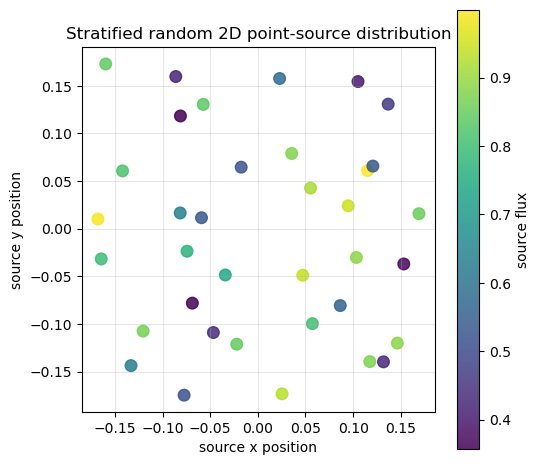

In [8]:
# Visualise random source positions and flux values.
fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(
    point_sources[:, 0],
    point_sources[:, 1],
    c=point_sources[:, 2],
    s=70,
    alpha=0.85,
)
ax.set_aspect("equal")
ax.set_xlabel("source x position")
ax.set_ylabel("source y position")
ax.set_title("Stratified random 2D point-source distribution")
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label="source flux")
plt.tight_layout()
plt.show()


## 3. Physical Kolmogorov Turbulence

The hidden atmospheric layers are generated in Fourier space using Kolmogorov statistics and then converted from phase to OPD.

The phase and OPD are related by

$$\phi(x,y)=\frac{2\pi}{\lambda}W(x,y).$$

For Kolmogorov turbulence, the phase power spectrum follows the characteristic high-frequency behaviour

$$\Phi_\phi(k)\propto k^{-11/3},$$

while the phase structure function follows

$$D_\phi(r)\approx 6.88\left(\frac{r}{r_0}\right)^{5/3}.$$

The total Fried parameter is derived from the selected seeing and wavelength, and the integrated turbulence strength is split between the two layers.

> **Key update:** turbulence amplitude is no longer an arbitrary weak perturbation. It is tied to a representative visible-light atmosphere through $r_0$.

> **Main difficulty:** a finite FFT grid cannot represent spatial frequencies below roughly the reciprocal of the screen size. Those missing low-frequency modes contain important large-scale wavefront structure, so the implementation adds iterative low-frequency compensation.


In [9]:
def xy_at_layer(x_source, y_source, x_lens, y_lens, z_layer):
    """Unperturbed ray position at a turbulent layer."""
    fraction = (z_layer - z_lenslet) / (z_source - z_lenslet)

    x_hit = x_lens + (x_source - x_lens) * fraction
    y_hit = y_lens + (y_source - y_lens) * fraction

    return x_hit, y_hit


In [10]:
# The layer screens must cover every ray intersection point.
all_layer_hits_x = []
all_layer_hits_y = []

for z_layer in z_layers:
    for x_source, y_source, flux in point_sources:
        for x_lens, y_lens in lenslet_centers_xy:
            x_hit, y_hit = xy_at_layer(
                x_source,
                y_source,
                x_lens,
                y_lens,
                z_layer,
            )
            all_layer_hits_x.append(x_hit)
            all_layer_hits_y.append(y_hit)

screen_extent = (
    max(
        aperture_radius,
        np.max(np.abs(all_layer_hits_x)),
        np.max(np.abs(all_layer_hits_y)),
    )
    + lenslet_pitch
)

kolmogorov_n_grid = 256
x_screen = np.linspace(-screen_extent, screen_extent, kolmogorov_n_grid)
y_screen = np.linspace(-screen_extent, screen_extent, kolmogorov_n_grid)

X_screen, Y_screen = np.meshgrid(x_screen, y_screen, indexing="xy")


In [11]:
def kolmogorov_phase_psd_from_k(k_radius, r0):
    """
    Kolmogorov phase power spectrum in angular spatial-frequency space.

    Phi_phi(k) is proportional to r0^(-5/3) k^(-11/3).
    The zero-frequency piston term is set to zero because piston does not affect
    ray tilt or imaging displacement.
    """
    psd = np.zeros_like(k_radius, dtype=float)
    nonzero = k_radius > 0
    psd[nonzero] = (r0 ** (-5 / 3)) * (k_radius[nonzero] ** (-11 / 3))
    return psd


def make_fourier_kolmogorov_phase(x_grid, y_grid, r0, seed):
    """
    Generate one base Kolmogorov phase screen from a random Fourier spectrum.

    The screen is generated in phase units, radians.  The Fourier coefficient
    amplitudes follow sqrt(Phi_phi), where Phi_phi(k) ∝ k^(-11/3).
    """
    rng = np.random.default_rng(seed)

    nx = len(x_grid)
    ny = len(y_grid)

    dx = x_grid[1] - x_grid[0]
    dy = y_grid[1] - y_grid[0]

    fx = np.fft.fftfreq(nx, d=dx)
    fy = np.fft.fftfreq(ny, d=dy)
    FX, FY = np.meshgrid(fx, fy, indexing="xy")

    k_radius = 2 * np.pi * np.sqrt(FX**2 + FY**2)
    psd_phase = kolmogorov_phase_psd_from_k(k_radius, r0)
    psd_phase[0, 0] = 0.0

    dfx = abs(fx[1] - fx[0])
    dfy = abs(fy[1] - fy[0])

    random_complex = rng.normal(size=(ny, nx)) + 1j * rng.normal(size=(ny, nx))
    spectrum = random_complex * np.sqrt(psd_phase * dfx * dfy)

    phase = np.fft.ifft2(spectrum).real * nx * ny
    phase = phase - np.mean(phase)

    return phase


def add_iterative_low_frequency_compensation(
    phase,
    x_grid,
    y_grid,
    r0,
    seed,
    n_iterations=4,
    samples_per_axis=3,
):
    """
    Add subharmonic low-frequency phase terms.

    A normal FFT screen only samples frequencies down to about 1 / screen_size.
    Real atmospheric turbulence also contains larger-scale, lower-frequency
    modes.  Here we iteratively sample frequencies below the FFT fundamental
    and add them as sinusoidal phase components.
    """
    rng = np.random.default_rng(seed)

    X, Y = np.meshgrid(x_grid, y_grid, indexing="xy")
    screen_size = max(x_grid[-1] - x_grid[0], y_grid[-1] - y_grid[0])

    compensated = phase.copy()

    # Use odd sampling so that the small frequency grid is centred on zero.
    offsets = np.arange(samples_per_axis) - samples_per_axis // 2

    for iteration in range(1, n_iterations + 1):
        df_low = 1.0 / ((3 ** iteration) * screen_size)

        for i in offsets:
            for j in offsets:
                if i == 0 and j == 0:
                    continue

                fx = i * df_low
                fy = j * df_low
                k_radius = 2 * np.pi * np.sqrt(fx**2 + fy**2)

                psd_value = kolmogorov_phase_psd_from_k(
                    np.array([[k_radius]]),
                    r0,
                )[0, 0]

                coefficient = (
                    rng.normal() + 1j * rng.normal()
                ) * np.sqrt(psd_value * df_low**2)

                compensated += np.real(
                    coefficient * np.exp(1j * 2 * np.pi * (fx * X + fy * Y))
                )

    compensated = compensated - np.mean(compensated)
    return compensated


In [12]:
def phase_structure_function_fft(phase, x_grid, y_grid, n_bins=50, max_radius_fraction=0.45):
    """
    Estimate the phase structure function D_phi(r) = <[phi(x+r)-phi(x)]^2>.

    The estimate uses the autocovariance relation D_phi(r) = 2[var(phi)-C(r)]
    and then radially averages the result.
    """
    phase_zero_mean = phase - np.mean(phase)

    ny, nx = phase_zero_mean.shape
    dx = x_grid[1] - x_grid[0]
    dy = y_grid[1] - y_grid[0]

    spectrum = np.fft.fft2(phase_zero_mean)
    autocov = np.fft.ifft2(np.abs(spectrum) ** 2).real / (nx * ny)
    autocov = np.fft.fftshift(autocov)

    var_phase = np.var(phase_zero_mean)
    D_map = 2 * (var_phase - autocov)

    lag_x = (np.arange(nx) - nx // 2) * dx
    lag_y = (np.arange(ny) - ny // 2) * dy
    LX, LY = np.meshgrid(lag_x, lag_y, indexing="xy")
    R = np.sqrt(LX**2 + LY**2)

    max_radius = max_radius_fraction * min(
        x_grid[-1] - x_grid[0],
        y_grid[-1] - y_grid[0],
    )

    valid = (R > 0) & (R <= max_radius)
    bin_edges = np.linspace(0, max_radius, n_bins + 1)

    r_values = []
    D_values = []

    for b0, b1 in zip(bin_edges[:-1], bin_edges[1:]):
        mask = valid & (R >= b0) & (R < b1)
        if np.any(mask):
            r_values.append(np.mean(R[mask]))
            D_values.append(np.mean(D_map[mask]))

    return np.array(r_values), np.array(D_values)


def kolmogorov_structure_function_theory(r, r0):
    """Theoretical Kolmogorov phase structure function."""
    return 6.88 * (r / r0) ** (5 / 3)


def scale_phase_to_structure_function(
    phase,
    x_grid,
    y_grid,
    r0,
    fit_min_fraction=0.05,
    fit_max_fraction=0.35,
):
    """
    Rescale the generated phase so that its mid-range structure function follows
    D_phi(r) = 6.88 (r / r0)^(5/3).

    This keeps r0 physically meaningful while still allowing the random screen
    to be generated with a clear k^(-11/3) spectral shape.
    """
    r_values, D_measured = phase_structure_function_fft(phase, x_grid, y_grid)
    D_theory = kolmogorov_structure_function_theory(r_values, r0)

    screen_size = min(x_grid[-1] - x_grid[0], y_grid[-1] - y_grid[0])
    fit_mask = (
        np.isfinite(D_measured)
        & (D_measured > 0)
        & (r_values > fit_min_fraction * screen_size)
        & (r_values < fit_max_fraction * screen_size)
    )

    if not np.any(fit_mask):
        raise RuntimeError("No valid radial bins were available for structure-function scaling.")

    scale_factor = np.sqrt(np.median(D_theory[fit_mask] / D_measured[fit_mask]))
    phase_scaled = phase * scale_factor

    return phase_scaled


def remove_phase_piston(phase):
    """Remove piston only.  Large-scale tilt is kept as part of the turbulence."""
    return phase - np.mean(phase)


def phase_to_opd_and_slopes(phase, x_grid, y_grid, wavelength):
    """
    Convert phase in radians to OPD W and compute local OPD slopes.

    phase = 2 pi W / wavelength, therefore W = phase * wavelength / (2 pi).
    """
    W = phase * wavelength / (2 * np.pi)
    dWdy, dWdx = np.gradient(W, y_grid, x_grid)
    return W, dWdx, dWdy


In [13]:
def make_kolmogorov_phase_screen_v25(
    x_grid,
    y_grid,
    r0,
    wavelength,
    seed,
    low_frequency_iterations=4,
    low_frequency_samples_per_axis=3,
):
    """
    Generate one physically improved Kolmogorov turbulent phase screen.

    Steps
    -----
    1. Generate a random Fourier-domain phase spectrum with Phi(k) ∝ k^(-11/3).
    2. Add iterative low-frequency / subharmonic compensation.
    3. Scale the phase using the theoretical structure function.
    4. Convert phase to OPD W and compute dW/dx, dW/dy for the existing
       ray-tracing and reconstruction pipeline.
    """
    phase_base = make_fourier_kolmogorov_phase(
        x_grid=x_grid,
        y_grid=y_grid,
        r0=r0,
        seed=seed,
    )

    phase_with_low_freq = add_iterative_low_frequency_compensation(
        phase=phase_base,
        x_grid=x_grid,
        y_grid=y_grid,
        r0=r0,
        seed=seed + 10_000,
        n_iterations=low_frequency_iterations,
        samples_per_axis=low_frequency_samples_per_axis,
    )

    phase_scaled = scale_phase_to_structure_function(
        phase=phase_with_low_freq,
        x_grid=x_grid,
        y_grid=y_grid,
        r0=r0,
    )

    phase_scaled = remove_phase_piston(phase_scaled)
    W, dWdx, dWdy = phase_to_opd_and_slopes(
        phase=phase_scaled,
        x_grid=x_grid,
        y_grid=y_grid,
        wavelength=wavelength,
    )

    return {
        "phase": phase_scaled,
        "W": W,
        "dWdx": dWdx,
        "dWdy": dWdy,
    }


def validate_kolmogorov_structure_function(layer, n_bins=55):
    """
    Compute measured and theoretical structure functions for one layer.
    """
    r_values, D_measured = phase_structure_function_fft(
        phase=layer["phase"],
        x_grid=layer["x_screen"],
        y_grid=layer["y_screen"],
        n_bins=n_bins,
    )

    D_theory = kolmogorov_structure_function_theory(
        r_values,
        layer["r0"],
    )

    return r_values, D_measured, D_theory


In [14]:
# Representative ground-based Kolmogorov atmosphere.
# Geometry is interpreted in metres and the turbulence is specified at 500 nm.
# A seeing FWHM of about 1 arcsec is a moderate, realistic visible-light case.

wavelength_observation = 500e-9
seeing_arcsec = 1.0
seeing_rad = np.deg2rad(seeing_arcsec / 3600.0)

# Long-exposure seeing relation: epsilon approximately 0.98 lambda / r0.
r0_total = 0.98 * wavelength_observation / seeing_rad

# Split the integrated Cn^2 strength between the two layers.
# If f_l is the strength fraction, r0_l^(-5/3) = f_l r0_total^(-5/3).
layer_strength_fractions = np.array([0.60, 0.40])
r0_layers = r0_total * layer_strength_fractions ** (-3 / 5)

wavelength_turbulence = wavelength_observation
low_frequency_iterations = 4
low_frequency_samples_per_axis = 3

turbulent_layers = [
    {
        "name": "W1 / Layer 1",
        "z": z_layers[0],
        "seed": 4,
        "strength_fraction": float(layer_strength_fractions[0]),
        "r0": float(r0_layers[0]),
        "screen_size": 2 * screen_extent,
        "pixel_scale": x_screen[1] - x_screen[0],
    },
    {
        "name": "W2 / Layer 2",
        "z": z_layers[1],
        "seed": 12,
        "strength_fraction": float(layer_strength_fractions[1]),
        "r0": float(r0_layers[1]),
        "screen_size": 2 * screen_extent,
        "pixel_scale": x_screen[1] - x_screen[0],
    },
]

r0_combined_check = (
    sum(layer["r0"] ** (-5 / 3) for layer in turbulent_layers)
) ** (-3 / 5)

print("Typical atmospheric Kolmogorov configuration — v2.5.3")
print(f"Observation wavelength: {wavelength_observation * 1e9:.0f} nm")
print(f"Target seeing: {seeing_arcsec:.2f} arcsec")
print(f"Total Fried parameter r0: {r0_total:.3f} m")
print(f"Combined-r0 check: {r0_combined_check:.3f} m")
print(f"Aperture diameter / r0: {2 * aperture_radius / r0_total:.2f}")
print(f"screen_size = {2 * screen_extent:.3e} m")
print(f"pixel_scale = {x_screen[1] - x_screen[0]:.3e} m")

for layer in turbulent_layers:
    print(
        f"{layer['name']}: z={layer['z']:.2f} m, "
        f"strength={100 * layer['strength_fraction']:.0f}%, "
        f"r0={layer['r0']:.3f} m, grid={kolmogorov_n_grid}x{kolmogorov_n_grid}"
    )

Typical atmospheric Kolmogorov configuration — v2.5.3
Observation wavelength: 500 nm
Target seeing: 1.00 arcsec
Total Fried parameter r0: 0.101 m
Combined-r0 check: 0.101 m
Aperture diameter / r0: 3.91
screen_size = 4.394e-01 m
pixel_scale = 1.723e-03 m
W1 / Layer 1: z=0.35 m, strength=60%, r0=0.137 m, grid=256x256
W2 / Layer 2: z=0.70 m, strength=40%, r0=0.175 m, grid=256x256


W1 / Layer 1: phase RMS=1.825 rad, OPD RMS=1.452e-07
W2 / Layer 2: phase RMS=1.289 rad, OPD RMS=1.026e-07


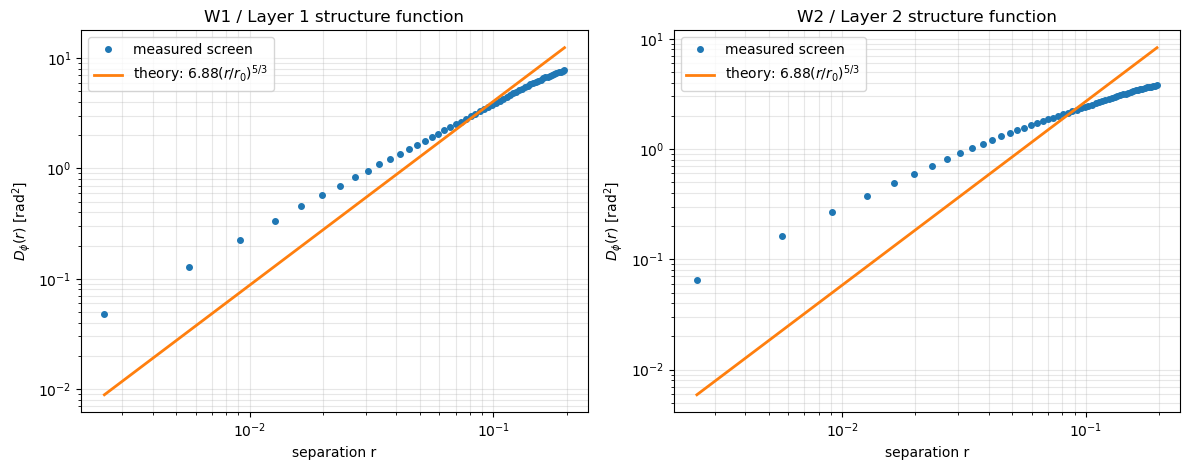

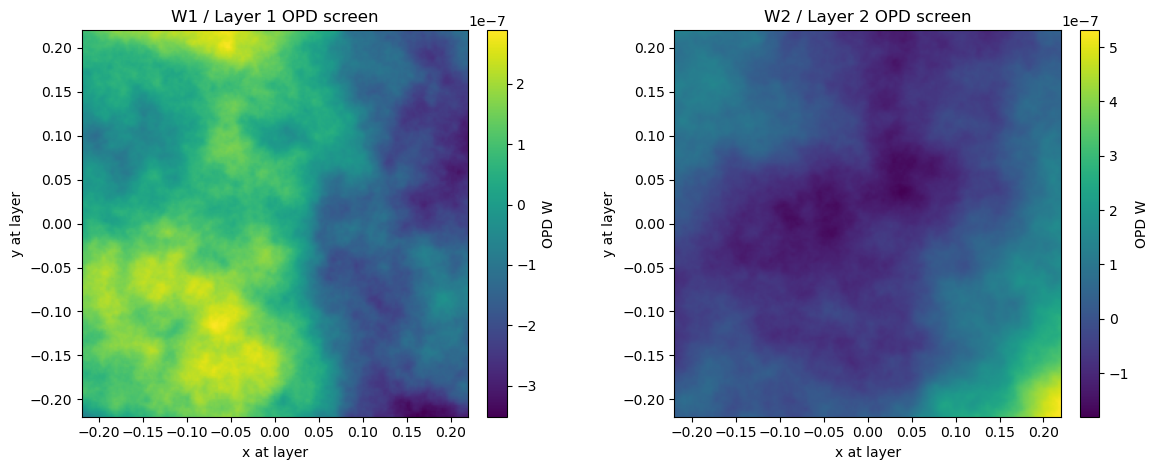

In [15]:
for layer in turbulent_layers:
    screen = make_kolmogorov_phase_screen_v25(
        x_grid=x_screen,
        y_grid=y_screen,
        r0=layer["r0"],
        wavelength=wavelength_turbulence,
        seed=layer["seed"],
        low_frequency_iterations=low_frequency_iterations,
        low_frequency_samples_per_axis=low_frequency_samples_per_axis,
    )

    layer["x_screen"] = x_screen
    layer["y_screen"] = y_screen
    layer["phase"] = screen["phase"]
    layer["W"] = screen["W"]
    layer["dWdx"] = screen["dWdx"]
    layer["dWdy"] = screen["dWdy"]

    print(
        f"{layer['name']}: phase RMS={np.std(layer['phase']):.3f} rad, "
        f"OPD RMS={np.std(layer['W']):.3e}"
    )


fig, axes = plt.subplots(1, len(turbulent_layers), figsize=(6 * len(turbulent_layers), 4.8))
if len(turbulent_layers) == 1:
    axes = [axes]

for ax, layer in zip(axes, turbulent_layers):
    r_values, D_measured, D_theory = validate_kolmogorov_structure_function(layer)

    ax.loglog(r_values, D_measured, "o", markersize=4, label="measured screen")
    ax.loglog(r_values, D_theory, "-", linewidth=2, label=r"theory: $6.88(r/r_0)^{5/3}$")

    ax.set_title(f"{layer['name']} structure function")
    ax.set_xlabel("separation r")
    ax.set_ylabel(r"$D_\phi(r)$ [rad$^2$]")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, len(turbulent_layers), figsize=(6 * len(turbulent_layers), 4.8))
if len(turbulent_layers) == 1:
    axes = [axes]

extent_screen = [x_screen[0], x_screen[-1], y_screen[0], y_screen[-1]]

for ax, layer in zip(axes, turbulent_layers):
    image = ax.imshow(
        layer["W"],
        origin="lower",
        extent=extent_screen,
        aspect="equal",
    )
    ax.set_title(f"{layer['name']} OPD screen")
    ax.set_xlabel("x at layer")
    ax.set_ylabel("y at layer")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="OPD W")

plt.tight_layout()
plt.show()


### 3.1 OPD and Local Tilt Sampling

The forward model samples the hidden OPD and its gradients at each ray-layer intersection.

The local angular perturbations are approximated by

$$\theta_x\approx\frac{\partial W}{\partial x},\qquad \theta_y\approx\frac{\partial W}{\partial y}.$$

Bilinear interpolation is used because a ray generally intersects a layer between phase-screen pixels.

> **Important separation:** these hidden values are available only inside the forward simulator. The estimator later receives images and known geometry, not the true local slopes.


In [16]:
def interp2_uniform(x_grid, y_grid, image, x, y):
    """Bilinear interpolation on a uniformly sampled 2D grid."""
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    dx = x_grid[1] - x_grid[0]
    dy = y_grid[1] - y_grid[0]

    xi = (x_arr - x_grid[0]) / dx
    yi = (y_arr - y_grid[0]) / dy

    i0 = np.floor(xi).astype(int)
    j0 = np.floor(yi).astype(int)

    i0 = np.clip(i0, 0, len(x_grid) - 2)
    j0 = np.clip(j0, 0, len(y_grid) - 2)

    wx = np.clip(xi - i0, 0.0, 1.0)
    wy = np.clip(yi - j0, 0.0, 1.0)

    z00 = image[j0, i0]
    z10 = image[j0, i0 + 1]
    z01 = image[j0 + 1, i0]
    z11 = image[j0 + 1, i0 + 1]

    value = (
        (1 - wx) * (1 - wy) * z00
        + wx * (1 - wy) * z10
        + (1 - wx) * wy * z01
        + wx * wy * z11
    )

    if np.isscalar(x) and np.isscalar(y):
        return float(value)

    return value


In [17]:
def layer_opd(layer, x, y):
    return interp2_uniform(layer["x_screen"], layer["y_screen"], layer["W"], x, y)


def layer_tilt_x(layer, x, y):
    return interp2_uniform(layer["x_screen"], layer["y_screen"], layer["dWdx"], x, y)


def layer_tilt_y(layer, x, y):
    return interp2_uniform(layer["x_screen"], layer["y_screen"], layer["dWdy"], x, y)


In [18]:
def total_turbulent_tilt(x_source, y_source, x_lens, y_lens):
    """Total ray-angle perturbation from both turbulent layers."""
    per_layer_tilts_x = []
    per_layer_tilts_y = []
    per_layer_hits = []

    for layer in turbulent_layers:
        x_hit, y_hit = xy_at_layer(
            x_source,
            y_source,
            x_lens,
            y_lens,
            layer["z"]
        )

        tx = layer_tilt_x(layer, x_hit, y_hit)
        ty = layer_tilt_y(layer, x_hit, y_hit)

        per_layer_hits.append((x_hit, y_hit))
        per_layer_tilts_x.append(tx)
        per_layer_tilts_y.append(ty)

    return (
        np.sum(per_layer_tilts_x),
        np.sum(per_layer_tilts_y),
        per_layer_tilts_x,
        per_layer_tilts_y,
        per_layer_hits,
    )


print(f"Screen x/y range: {-screen_extent:.3f} to {screen_extent:.3f}")


Screen x/y range: -0.220 to 0.220


## 4. 2D Forward Ray Tracing

Each source-lenslet ray intersects both hidden layers at source-dependent positions. The two local tilt contributions are added to the nominal source angle and propagated to the microlens sensor.

For one ray, the turbulent contribution is conceptually

$$\boldsymbol{\theta}_{\mathrm{turb}}=\boldsymbol{T}_1(x_1,y_1)+\boldsymbol{T}_2(x_2,y_2).$$

> **Key idea:** the sensor measures the combined effect along a ray. Tomography must infer how much of that measurement came from each hidden layer.


In [19]:
def ray_source_angles(x_source, y_source, x_lens, y_lens):
    """Angles from source point to lenslet centre."""
    theta_source_x = np.arctan2(x_lens - x_source, z_source - z_lenslet)
    theta_source_y = np.arctan2(y_lens - y_source, z_source - z_lenslet)

    return theta_source_x, theta_source_y


In [20]:
def zero_turbulence_terms(x_source, y_source, x_lens, y_lens):
    """Return zero layer perturbations for a no-turbulence ray."""
    per_layer_hits = [
        xy_at_layer(x_source, y_source, x_lens, y_lens, layer["z"])
        for layer in turbulent_layers
    ]

    return (
        0.0,
        0.0,
        [0.0 for _ in turbulent_layers],
        [0.0 for _ in turbulent_layers],
        per_layer_hits,
    )


In [21]:
def trace_one_ray(x_source, y_source, x_lens, y_lens, use_turbulence=True):
    """Trace one source-lenslet ray to the sensor."""
    theta_source_x, theta_source_y = ray_source_angles(
        x_source,
        y_source,
        x_lens,
        y_lens,
    )

    if use_turbulence:
        turbulence_terms = total_turbulent_tilt(
            x_source,
            y_source,
            x_lens,
            y_lens,
        )
    else:
        turbulence_terms = zero_turbulence_terms(
            x_source,
            y_source,
            x_lens,
            y_lens,
        )

    (
        theta_turbulence_x,
        theta_turbulence_y,
        per_layer_tilts_x,
        per_layer_tilts_y,
        per_layer_hits,
    ) = turbulence_terms

    theta_total_x = theta_source_x + theta_turbulence_x
    theta_total_y = theta_source_y + theta_turbulence_y

    x_spot = x_lens - f_ml * np.tan(theta_total_x)
    y_spot = y_lens - f_ml * np.tan(theta_total_y)

    return {
        "x_source": x_source,
        "y_source": y_source,
        "x_lens": x_lens,
        "y_lens": y_lens,
        "theta_source_x": theta_source_x,
        "theta_source_y": theta_source_y,
        "theta_turbulence_x": theta_turbulence_x,
        "theta_turbulence_y": theta_turbulence_y,
        "theta_total_x": theta_total_x,
        "theta_total_y": theta_total_y,
        "x_spot": x_spot,
        "y_spot": y_spot,
        "per_layer_tilts_x": per_layer_tilts_x,
        "per_layer_tilts_y": per_layer_tilts_y,
        "per_layer_hits": per_layer_hits,
    }


In [22]:
rays_no_turbulence = []
rays_with_turbulence = []

for source_id, (x_source, y_source, flux) in enumerate(point_sources):
    for lenslet_id, (x_lens, y_lens) in enumerate(lenslet_centers_xy):

        ray_no = trace_one_ray(
            x_source,
            y_source,
            x_lens,
            y_lens,
            use_turbulence=False
        )

        ray_with = trace_one_ray(
            x_source,
            y_source,
            x_lens,
            y_lens,
            use_turbulence=True
        )

        extra_info = {
            "source_id": source_id,
            "lenslet_id": lenslet_id,
            "flux": flux,
        }

        ray_no.update(extra_info)
        ray_with.update(extra_info)

        rays_no_turbulence.append(ray_no)
        rays_with_turbulence.append(ray_with)

print(f"Total rays: {len(rays_with_turbulence)}")


Total rays: 6084


In [23]:
# Hidden truth is intentionally not plotted before estimation.
# The true turbulent layers are kept only for generating simulated observations
# and for validation after the reconstruction has been completed.

print("Two hidden turbulent layers have been generated.")
print("They will not be used in reference-free tilt estimation or tomography.")
print("Hidden truth plots are shown only in the final validation cells.")


Two hidden turbulent layers have been generated.
They will not be used in reference-free tilt estimation or tomography.
Hidden truth plots are shown only in the final validation cells.


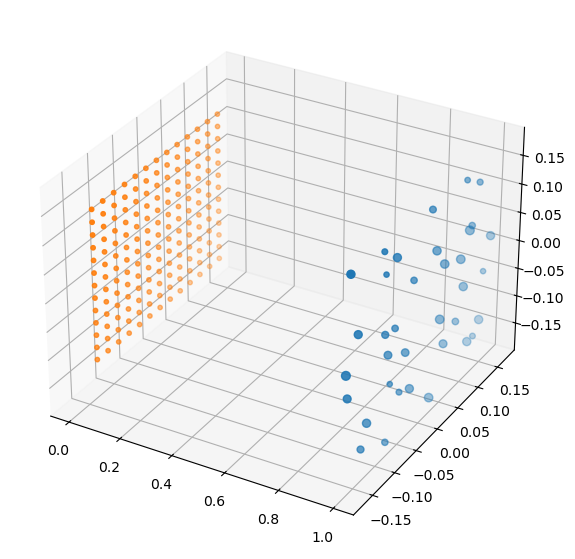

In [24]:
# Ray-tracing plot setup.
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    np.full(n_sources, z_source),
    point_sources[:, 0],
    point_sources[:, 1],
    s=40 * point_sources[:, 2],
    label="Point sources",
)

ax.scatter(
    np.full(n_lenslet_total, z_lenslet),
    lenslet_centers_xy[:, 0],
    lenslet_centers_xy[:, 1],
    s=10,
    label="Lenslet centres",
)

draw_source_ids = [0, n_sources // 2, n_sources - 1]
draw_lenslet_ids = np.linspace(0, n_lenslet_total - 1, 17, dtype=int)


In [25]:
# Draw a small subset of observed turbulent rays.
for r_with in rays_with_turbulence:
    if r_with["source_id"] not in draw_source_ids:
        continue
    if r_with["lenslet_id"] not in draw_lenslet_ids:
        continue

    ax.plot(
        [z_source, z_lenslet, z_sensor],
        [r_with["x_source"], r_with["x_lens"], r_with["x_spot"]],
        [r_with["y_source"], r_with["y_lens"], r_with["y_spot"]],
        alpha=0.55,
    )

for z_layer in z_layers:
    ax.plot(
        [z_layer, z_layer],
        [-aperture_radius, aperture_radius],
        [0, 0],
        linestyle="--",
        linewidth=1.5,
        label=f"Turbulent layer z={z_layer:.2f}",
    )


In [26]:
# Finalise the ray-tracing plot.
ax.set_xlabel("z")
ax.set_ylabel("x")
ax.set_zlabel("y")
ax.set_title("Observed ray tracing with two turbulent layers")
ax.legend(loc="upper left")
ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

## 5. Source-Wise Self-Referenced WFS Measurement

This is the major estimator update relative to the simple clean-reference model.

For source $s$ and lenslet $i$, only the observed image tile is used:

$$I_{\mathrm{obs}}[i,s](p)=F_sP(p-p_{0,s}-\Delta p_{i,s})+\mathrm{noise}.$$

No clean reference image, true displacement, true tilt, or hidden OPD is used by the image-registration estimator.

For one source, pairwise displacement is defined as

$$\hat d_{ij,s}\approx a_{i,s}-a_{j,s},$$

and all pairwise relations are solved together:

$$a_{i,s}-a_{j,s}=\hat d_{ij,s}.$$

Because only differences are measured, one common displacement per source is unobservable. The gauge is fixed with

$$\sum_i a_{i,s}=0.$$

The relative tilt is then

$$\tau_{i,s}^{\mathrm{rel}}=\frac{a_{i,s}}{f_{\mathrm{ml}}}.$$

> **Key update:** the estimator is now **self-referenced**.

> **Main difficulty:** self-reference removes dependence on a hidden clean image, but it also removes absolute common-mode tilt. The tomography must therefore work with source-wise relative measurements.


In [27]:
# Example IDs for diagnostics.
plot_lenslet_ids = [
    0,
    n_lenslet_total // 2,
    n_lenslet_total - 1,
]

plot_source_ids = [
    0,
    len(point_sources) // 2,
    len(point_sources) - 1,
]

In [28]:
# Image and registration parameters.
single_n = 48
image_noise_std = 0.0       # add realistic detector noise after the noiseless baseline works
rng_image = np.random.default_rng(3)

flux_threshold_for_tilt = 0.35
pairwise_max_pairs_per_source = 350

# Physical detector coordinates for a 500 nm circular microlens.
# The ±35 micrometre tile samples the Airy core and several micrometres of tilt motion.
single_half_width = 35e-6
single_axis = np.linspace(-single_half_width, single_half_width, single_n)
single_dx = single_axis[1] - single_axis[0]
single_dy = single_dx

X_single, Y_single = np.meshgrid(single_axis, single_axis, indexing="xy")

wavelength_lenslet_psf = wavelength_observation
lenslet_pupil_n = 64
lenslet_pupil_axis = np.linspace(-lenslet_radius, lenslet_radius, lenslet_pupil_n)
lenslet_pupil_dx = lenslet_pupil_axis[1] - lenslet_pupil_axis[0]

X_lenslet_pupil, Y_lenslet_pupil = np.meshgrid(
    lenslet_pupil_axis,
    lenslet_pupil_axis,
    indexing="xy",
)

lenslet_pupil_mask = (
    X_lenslet_pupil**2 + Y_lenslet_pupil**2
) <= lenslet_radius**2

lenslet_focal_frequency_axis = single_axis / (wavelength_lenslet_psf * f_ml)

airy_first_zero_radius = 1.22 * wavelength_lenslet_psf * f_ml / (2 * lenslet_radius)
print(f"CZT physical PSF: pupil grid {lenslet_pupil_n} x {lenslet_pupil_n}")
print(f"Observation wavelength: {wavelength_lenslet_psf * 1e9:.0f} nm")
print(f"Airy first-zero radius: {airy_first_zero_radius * 1e6:.2f} micrometres")
print(f"Detector sampling dx: {single_dx * 1e6:.2f} micrometres")
print(f"Airy first-zero sampling: {airy_first_zero_radius / single_dx:.2f} pixels")

CZT physical PSF: pupil grid 64 x 64
Observation wavelength: 500 nm
Airy first-zero radius: 10.89 micrometres
Detector sampling dx: 1.49 micrometres
Airy first-zero sampling: 7.31 pixels


In [29]:
def make_uniform_czt_transform(sample_axis, frequency_axis):
    """Precompute a CZT object for one uniformly sampled Fourier axis."""
    sample_axis = np.asarray(sample_axis, dtype=float)
    frequency_axis = np.asarray(frequency_axis, dtype=float)

    dx = sample_axis[1] - sample_axis[0]
    x0 = sample_axis[0]
    du = frequency_axis[1] - frequency_axis[0]
    u0 = frequency_axis[0]
    m = len(frequency_axis)

    a = np.exp(2j * np.pi * dx * u0)
    w = np.exp(-2j * np.pi * dx * du)

    return {
        "m": m,
        "frequency_axis": frequency_axis,
        "origin_phase": np.exp(-2j * np.pi * x0 * frequency_axis),
        "czt": CZT(len(sample_axis), m=m, w=w, a=a),
    }


def czt_fourier_1d(samples, czt_transform, axis=-1):
    """Evaluate F(u)=sum_n f(x_n) exp(-i 2 pi x_n u) with a precomputed CZT."""
    transformed = czt_transform["czt"](samples, axis=axis)

    phase_shape = [1] * transformed.ndim
    phase_shape[axis] = czt_transform["m"]
    origin_phase = czt_transform["origin_phase"].reshape(phase_shape)

    return transformed * origin_phase


lenslet_czt_transform = make_uniform_czt_transform(
    lenslet_pupil_axis,
    lenslet_focal_frequency_axis,
)


def lenslet_physical_psf_czt(theta_turbulence_x, theta_turbulence_y, flux):
    """Generate one circular-microlens diffraction PSF using a 2D CZT.

    Local turbulence is represented as a pupil-plane tilt phase. The CZT then
    samples the Fraunhofer focal-plane field directly on the detector tile grid.
    """
    tilt_phase = np.exp(
        1j * 2 * np.pi
        * (
            theta_turbulence_x * X_lenslet_pupil
            + theta_turbulence_y * Y_lenslet_pupil
        )
        / wavelength_lenslet_psf
    )

    pupil_field = lenslet_pupil_mask.astype(float) * tilt_phase

    field_after_x = czt_fourier_1d(
        pupil_field,
        lenslet_czt_transform,
        axis=1,
    )

    focal_field = czt_fourier_1d(
        field_after_x,
        lenslet_czt_transform,
        axis=0,
    )

    intensity = np.abs(focal_field)**2
    intensity_sum = np.sum(intensity)

    if intensity_sum > 0:
        intensity = intensity / intensity_sum

    return flux * intensity


def add_detector_noise(image):
    """Add simple Gaussian detector noise."""
    image = image.copy()

    if image_noise_std > 0:
        image += rng_image.normal(0.0, image_noise_std, size=image.shape)
        image = np.clip(image, 0.0, None)

    return image


def display_normalise(image):
    """Normalise an image for plotting only."""
    image = image.copy()
    image = image - np.min(image)

    if np.max(image) > 0:
        image = image / np.max(image)

    return image


### 5.1 Physical Circular-Microlens PSF with CZT

Each observed tile is generated from a circular microlens pupil. Local wavefront tilt appears as a pupil-plane phase ramp, and the focal-plane intensity is sampled with a 2D **Chirp Z-Transform (CZT)**.

> **Key update:** Gaussian spots are replaced by a diffraction-based microlens image.

> **Why CZT:** the required detector sampling does not have to coincide with the fixed Fourier sampling of a standard FFT. CZT allows the focal region to be sampled directly at the desired physical detector scale.


In [30]:
def make_observed_single_source_tile(row):
    """Draw one observed source-lenslet tile using a CZT physical lenslet PSF.

    The local tile coordinate is centred on the nominal no-turbulence source
    position p0_s. The turbulent tilt is not estimated here; it is only used to
    generate the synthetic observation, as real hardware would provide the tile.
    """
    image = lenslet_physical_psf_czt(
        theta_turbulence_x=row["theta_turbulence_x"],
        theta_turbulence_y=row["theta_turbulence_y"],
        flux=row["flux"],
    )

    return add_detector_noise(image)


# Only observed turbulent images are passed to the estimator.
observed_rows = [
    r for r in rays_with_turbulence
    if r["flux"] >= flux_threshold_for_tilt
]

observed_tiles = []

for tile_id, row in enumerate(observed_rows):
    image = make_observed_single_source_tile(row)

    observed_tiles.append({
        "tile_id": tile_id,
        "source_id": row["source_id"],
        "lenslet_id": row["lenslet_id"],
        "x_source": row["x_source"],
        "y_source": row["y_source"],
        "x_lens": row["x_lens"],
        "y_lens": row["y_lens"],
        "flux": row["flux"],
        "image": image,
    })

print(f"Observed source-lenslet images used by estimator: {len(observed_tiles)}")
print(f"Skipped low-flux images: {len(rays_with_turbulence) - len(observed_tiles)}")
print(f"Detector tile range: ±{single_half_width * 1e6:.1f} micrometres")
print("Lenslet image formation: CZT-sampled physical diffraction PSF")


Observed source-lenslet images used by estimator: 6084
Skipped low-flux images: 0
Detector tile range: ±35.0 micrometres
Lenslet image formation: CZT-sampled physical diffraction PSF


### 5.2 Source Metadata and Tomographic Parallax

Each source keeps its own 2D source coordinate $(x_s,y_s)$. For layer $\ell$, a ray from source $s$ through lenslet $i$ intersects approximately at

$$x_{\ell,i,s}=x_i+z_\ell(x_s-x_i),$$

$$y_{\ell,i,s}=y_i+z_\ell(y_s-y_i).$$

> **Key update:** source identities are preserved instead of being averaged away.

> **Main difficulty:** the higher layer is especially sensitive to source position. Averaging multiple sources too early destroys the parallax information required for layer separation.


In [31]:
def build_source_info(point_sources, flux_threshold):
    """Build one metadata record for each usable individual source."""
    source_info = []

    for source_id, (x_source, y_source, flux) in enumerate(point_sources):
        if flux < flux_threshold:
            continue

        theta_x = np.arctan2(x_source - 0.0, z_source - z_lenslet)
        theta_y = np.arctan2(y_source - 0.0, z_source - z_lenslet)

        source_info.append({
            "source_index": len(source_info),
            "source_id": int(source_id),
            "x_source": float(x_source),
            "y_source": float(y_source),
            "theta_x": float(theta_x),
            "theta_y": float(theta_y),
            "flux": float(flux),
        })

    source_index_by_id = {
        info["source_id"]: info["source_index"]
        for info in source_info
    }

    return source_info, source_index_by_id


source_info, source_index_by_id = build_source_info(
    point_sources,
    flux_threshold=flux_threshold_for_tilt,
)

print(f"Usable individual sources: {len(source_info)} / {len(point_sources)}")

for info in source_info[:6]:
    print(
        f"Source {info['source_id']:2d}: "
        f"x={info['x_source']:+.3f}, y={info['y_source']:+.3f}, "
        f"theta=({info['theta_x']:+.3e}, {info['theta_y']:+.3e}) rad, "
        f"flux={info['flux']:.3f}"
    )

Usable individual sources: 36 / 36
Source  0: x=-0.133, y=-0.144, theta=(-1.324e-01, -1.427e-01) rad, flux=0.624
Source  1: x=-0.077, y=-0.175, theta=(-7.726e-02, -1.729e-01) rad, flux=0.516
Source  2: x=-0.022, y=-0.121, theta=(-2.215e-02, -1.206e-01) rad, flux=0.844
Source  3: x=+0.025, y=-0.173, theta=(+2.540e-02, -1.716e-01) rad, flux=0.930
Source  4: x=+0.117, y=-0.139, theta=(+1.170e-01, -1.385e-01) rad, flux=0.873
Source  5: x=+0.132, y=-0.140, theta=(+1.311e-01, -1.388e-01) rad, flux=0.429


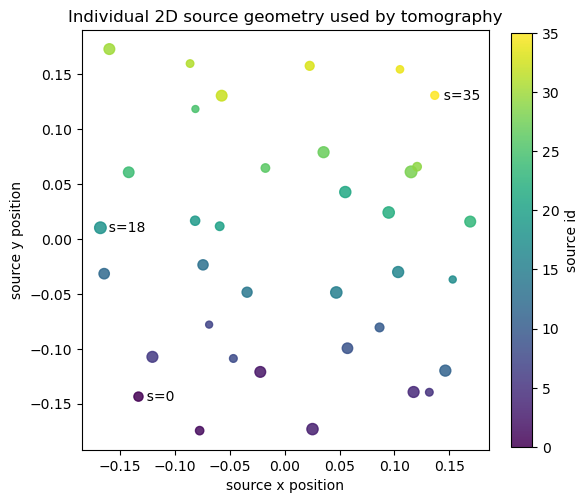

In [32]:
# Plot individual source positions and flux values.
fig, ax = plt.subplots(figsize=(5.8, 5.2))

used_source_ids = np.array([info["source_id"] for info in source_info], dtype=int)
used_sources = point_sources[used_source_ids]

scatter = ax.scatter(
    used_sources[:, 0],
    used_sources[:, 1],
    c=used_source_ids,
    s=70 * used_sources[:, 2] / np.max(used_sources[:, 2]),
    alpha=0.85,
)

for info in source_info:
    if info["source_id"] in plot_source_ids:
        ax.text(
            info["x_source"],
            info["y_source"],
            f"  s={info['source_id']}",
            va="center",
        )

ax.set_xlabel("source x position")
ax.set_ylabel("source y position")
ax.set_title("Individual 2D source geometry used by tomography")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, fraction=0.046, label="source id")
plt.tight_layout()
plt.show()

### 5.3 Source-Wise Observed Tiles

For each lenslet $i$ and source $s$, the estimator extracts the observed tile $I[i,s]$ directly. The patch is background-subtracted and flux-normalised before correlation.

No clean image alignment is performed.

The resulting tiles are physical CZT PSFs rather than Gaussian spots.


In [33]:
def extract_source_patch(
    tile,
    patch_radius_pix=None,
    subtract_background=True,
    flux_normalise=True,
):
    """Extract and normalise the observed patch for one source image."""
    image = tile["image"].astype(float)

    if patch_radius_pix is not None:
        cy = image.shape[0] // 2
        cx = image.shape[1] // 2
        y0 = max(cy - patch_radius_pix, 0)
        y1 = min(cy + patch_radius_pix + 1, image.shape[0])
        x0 = max(cx - patch_radius_pix, 0)
        x1 = min(cx + patch_radius_pix + 1, image.shape[1])
        patch = image[y0:y1, x0:x1].copy()
    else:
        patch = image.copy()

    if subtract_background:
        edge_values = np.concatenate([
            patch[0, :],
            patch[-1, :],
            patch[:, 0],
            patch[:, -1],
        ])
        patch = patch - np.median(edge_values)

    if flux_normalise:
        patch = patch / max(tile["flux"], 1e-12)

    return patch


def build_source_observed_tiles(
    observed_tiles,
    source_info,
    source_index_by_id,
    n_lenslet_total,
    patch_radius_pix=None,
):
    """Build I[i,s] observed tile array from observed data only."""
    n_sources_used = len(source_info)
    example_patch = extract_source_patch(observed_tiles[0], patch_radius_pix)

    source_tiles = np.zeros(
        (n_lenslet_total, n_sources_used, *example_patch.shape),
        dtype=float,
    )
    source_valid_mask = np.zeros((n_lenslet_total, n_sources_used), dtype=bool)
    source_tile_flux = np.zeros((n_lenslet_total, n_sources_used), dtype=float)

    for tile in observed_tiles:
        source_id = tile["source_id"]
        if source_id not in source_index_by_id:
            continue

        source_index = source_index_by_id[source_id]
        lenslet_id = tile["lenslet_id"]
        patch = extract_source_patch(tile, patch_radius_pix)

        source_tiles[lenslet_id, source_index] = patch
        source_valid_mask[lenslet_id, source_index] = True
        source_tile_flux[lenslet_id, source_index] = tile["flux"]

    return source_tiles, source_valid_mask, source_tile_flux


source_observed_tiles, source_valid_mask, source_tile_flux = build_source_observed_tiles(
    observed_tiles,
    source_info,
    source_index_by_id,
    n_lenslet_total=n_lenslet_total,
    patch_radius_pix=None,
)

print(f"Source-wise tile array I shape: {source_observed_tiles.shape}")
print(f"Valid lenslet-source observed tiles: {np.sum(source_valid_mask)}")

Source-wise tile array I shape: (169, 36, 48, 48)
Valid lenslet-source observed tiles: 6084


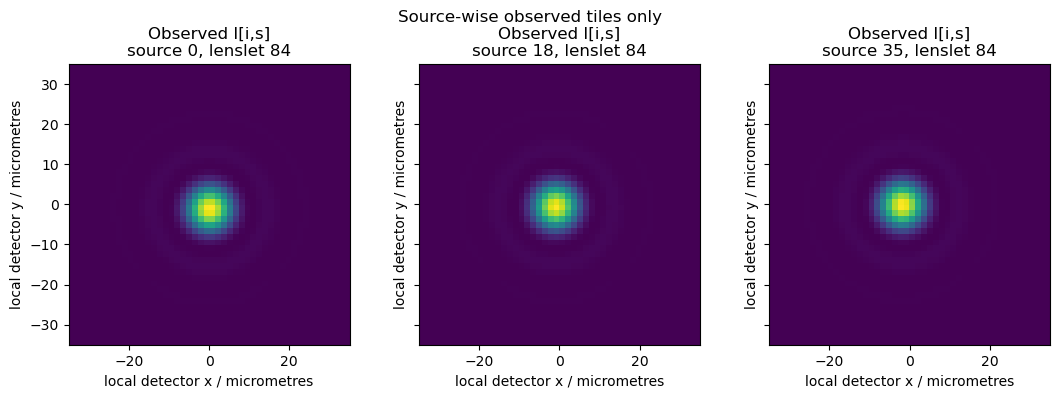

In [34]:
# Plot example observed source-wise tiles.
example_lenslet_id = n_lenslet_total // 2
example_source_indices = [
    0,
    len(source_info) // 2,
    len(source_info) - 1,
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharex=True, sharey=True)

for ax, source_index in zip(axes, example_source_indices):
    info = source_info[source_index]
    ax.imshow(
        display_normalise(source_observed_tiles[example_lenslet_id, source_index]),
        origin="lower",
        extent=[single_axis[0] * 1e6, single_axis[-1] * 1e6, single_axis[0] * 1e6, single_axis[-1] * 1e6],
        aspect="equal",
    )
    ax.set_title(
        f"Observed I[i,s]\n"
        f"source {info['source_id']}, lenslet {example_lenslet_id}"
    )
    ax.set_xlabel("local detector x / micrometres")
    ax.set_ylabel("local detector y / micrometres")

plt.suptitle("Source-wise observed tiles only")
plt.tight_layout()
plt.show()

### 5.4 Pairwise Normalized Cross-Correlation

For each individual source, observed tiles from different lenslets are compared using normalized cross-correlation.

The reported displacement convention is

$$\hat d_{ij,s}=a_{i,s}-a_{j,s}.$$

> **Main difficulty:** the raw correlation lag convention and the displacement convention have opposite signs in this implementation. Keeping the sign convention consistent is essential because an incorrect sign propagates directly into the reconstructed wavefront slope.


In [35]:
def zero_mean_for_ncc(image, eps=1e-12):
    """Subtract the mean and return a stable zero-mean NCC image."""
    image_zero_mean = image - np.mean(image)
    norm = np.sqrt(np.sum(image_zero_mean**2))

    if norm < eps:
        return image_zero_mean, eps

    return image_zero_mean, norm


def subpixel_peak_offset(left, centre, right):
    """Parabolic subpixel peak refinement around an integer peak."""
    denominator = left - 2 * centre + right

    if np.abs(denominator) < 1e-12:
        return 0.0

    return 0.5 * (left - right) / denominator


def apply_registration_window(image):
    """Apply a 2D Hann window to reduce FFT edge artefacts in NCC."""
    wy = np.hanning(image.shape[0])
    wx = np.hanning(image.shape[1])
    window = np.outer(wy, wx)
    return image * window


def prepare_ncc_tile(image, full_shape=None, use_window=True):
    """Precompute FFT terms for repeated source-wise NCC comparisons."""
    if use_window:
        image = apply_registration_window(image)

    image_zero_mean, norm = zero_mean_for_ncc(image)

    if full_shape is None:
        full_shape = (
            2 * image_zero_mean.shape[0] - 1,
            2 * image_zero_mean.shape[1] - 1,
        )

    return {
        "shape": image_zero_mean.shape,
        "full_shape": full_shape,
        "norm": norm,
        "fft_image": np.fft.rfftn(image_zero_mean, s=full_shape, axes=(0, 1)),
        "fft_reversed": np.fft.rfftn(image_zero_mean[::-1, ::-1], s=full_shape, axes=(0, 1)),
    }


def normalized_cross_correlation_prepared(
    prepared_i,
    prepared_j,
    dx,
    dy,
    use_subpixel=True,
):
    """Pairwise NCC displacement using precomputed FFTs.

    Returns d_ij = a_i - a_j in detector-coordinate units.
    Positive d_x means image i is shifted to larger x than image j.
    """
    full_shape = prepared_i["full_shape"]
    image_shape = prepared_i["shape"]

    correlation = np.fft.irfftn(
        prepared_j["fft_image"] * prepared_i["fft_reversed"],
        s=full_shape,
        axes=(0, 1),
    ) / (prepared_i["norm"] * prepared_j["norm"] + 1e-12)

    peak_y, peak_x = np.unravel_index(np.argmax(correlation), correlation.shape)
    lag_y_pix = peak_y - (image_shape[0] - 1)
    lag_x_pix = peak_x - (image_shape[1] - 1)

    if use_subpixel and 0 < peak_y < correlation.shape[0] - 1:
        lag_y_pix += subpixel_peak_offset(
            correlation[peak_y - 1, peak_x],
            correlation[peak_y, peak_x],
            correlation[peak_y + 1, peak_x],
        )

    if use_subpixel and 0 < peak_x < correlation.shape[1] - 1:
        lag_x_pix += subpixel_peak_offset(
            correlation[peak_y, peak_x - 1],
            correlation[peak_y, peak_x],
            correlation[peak_y, peak_x + 1],
        )

    # FFT lag gives approximately a_j - a_i. The reported d_ij is a_i - a_j.
    d_x = -lag_x_pix * dx
    d_y = -lag_y_pix * dy

    peak_value = correlation[peak_y, peak_x]

    # A simple peak-sharpness confidence: high if the NCC peak stands above the map background.
    corr_median = np.median(correlation)
    corr_mad = np.median(np.abs(correlation - corr_median)) + 1e-12
    peak_sharpness = (peak_value - corr_median) / corr_mad

    lag_x_axis = (np.arange(correlation.shape[1]) - (image_shape[1] - 1)) * dx
    lag_y_axis = (np.arange(correlation.shape[0]) - (image_shape[0] - 1)) * dy
    d_x_axis = -lag_x_axis
    d_y_axis = -lag_y_axis

    return {
        "d_x": d_x,
        "d_y": d_y,
        "peak": peak_value,
        "peak_sharpness": peak_sharpness,
        "correlation": correlation,
        "peak_y": peak_y,
        "peak_x": peak_x,
        "d_x_axis": d_x_axis,
        "d_y_axis": d_y_axis,
    }

In [36]:
def choose_lenslet_pairs(lenslet_ids, max_pairs=None, rng=None):
    """Choose lenslet pairs with a connected local graph plus random baselines.

    The local 4-neighbour graph keeps the source-wise shift solve connected.
    Extra random long-baseline pairs improve global consistency without using
    every possible pair.
    """
    lenslet_ids = np.array(sorted(lenslet_ids), dtype=int)
    lenslet_set = set(lenslet_ids.tolist())

    all_pairs = [
        (int(lenslet_ids[a]), int(lenslet_ids[b]))
        for a in range(len(lenslet_ids))
        for b in range(a + 1, len(lenslet_ids))
    ]

    if max_pairs is None or len(all_pairs) <= max_pairs:
        return all_pairs

    if rng is None:
        rng = np.random.default_rng(0)

    # 4-neighbour lenslet graph. This is connected for the full rectangular array.
    local_pairs = []
    lenslet_id_grid = np.arange(n_lenslet_total).reshape(n_lenslets, n_lenslets)

    for row in range(n_lenslets):
        for col in range(n_lenslets):
            i = int(lenslet_id_grid[row, col])
            if i not in lenslet_set:
                continue

            if col + 1 < n_lenslets:
                j = int(lenslet_id_grid[row, col + 1])
                if j in lenslet_set:
                    local_pairs.append((min(i, j), max(i, j)))

            if row + 1 < n_lenslets:
                j = int(lenslet_id_grid[row + 1, col])
                if j in lenslet_set:
                    local_pairs.append((min(i, j), max(i, j)))

    local_pairs = sorted(set(local_pairs))

    if len(local_pairs) >= max_pairs:
        # Keep a connected local graph as much as possible by returning local pairs first.
        return local_pairs[:max_pairs]

    pair_set = set(local_pairs)
    candidate_pairs = [pair for pair in all_pairs if pair not in pair_set]
    n_extra = max_pairs - len(local_pairs)

    if n_extra > 0 and len(candidate_pairs) > 0:
        chosen = rng.choice(len(candidate_pairs), size=min(n_extra, len(candidate_pairs)), replace=False)
        for k in chosen:
            pair_set.add(candidate_pairs[int(k)])

    return sorted(pair_set)


def estimate_pairwise_displacements(
    source_observed_tiles,
    valid_mask,
    source_info,
    dx,
    dy,
    max_pairs_per_source=None,
    use_subpixel=True,
    rng=None,
):
    """Estimate pairwise relative displacements d_ij,s for every individual source."""
    if rng is None:
        rng = np.random.default_rng(0)

    pair_i = []
    pair_j = []
    pair_source_index = []
    pair_source_id = []
    pair_dx = []
    pair_dy = []
    pair_peak = []
    pair_sharpness = []
    example_ncc = None

    n_lenslets_here, n_sources_used = valid_mask.shape

    for source_index in range(n_sources_used):
        info = source_info[source_index]
        lenslet_ids = np.where(valid_mask[:, source_index])[0]
        selected_pairs = choose_lenslet_pairs(
            lenslet_ids,
            max_pairs=max_pairs_per_source,
            rng=rng,
        )

        full_shape = (
            2 * source_observed_tiles.shape[-2] - 1,
            2 * source_observed_tiles.shape[-1] - 1,
        )
        prepared_tiles = {
            int(lenslet_id): prepare_ncc_tile(
                source_observed_tiles[int(lenslet_id), source_index],
                full_shape=full_shape,
                use_window=True,
            )
            for lenslet_id in lenslet_ids
        }

        for i, j in selected_pairs:
            result = normalized_cross_correlation_prepared(
                prepared_tiles[i],
                prepared_tiles[j],
                dx,
                dy,
                use_subpixel=use_subpixel,
            )

            pair_i.append(i)
            pair_j.append(j)
            pair_source_index.append(source_index)
            pair_source_id.append(info["source_id"])
            pair_dx.append(result["d_x"])
            pair_dy.append(result["d_y"])
            pair_peak.append(result["peak"])
            pair_sharpness.append(result["peak_sharpness"])

            if example_ncc is None:
                example_ncc = {
                    "i": i,
                    "j": j,
                    "source_index": source_index,
                    "source_id": info["source_id"],
                    **result,
                }

    return {
        "i": np.array(pair_i, dtype=int),
        "j": np.array(pair_j, dtype=int),
        "source_index": np.array(pair_source_index, dtype=int),
        "source_id": np.array(pair_source_id, dtype=int),
        "dx_ij": np.array(pair_dx),
        "dy_ij": np.array(pair_dy),
        "peak": np.array(pair_peak),
        "peak_sharpness": np.array(pair_sharpness),
        "example_ncc": example_ncc,
    }


pair_data = estimate_pairwise_displacements(
    source_observed_tiles,
    source_valid_mask,
    source_info,
    single_dx,
    single_dy,
    max_pairs_per_source=pairwise_max_pairs_per_source,
    use_subpixel=True,
    rng=np.random.default_rng(42),
)

print(f"Pairwise source-wise NCC measurements: {len(pair_data['dx_ij'])}")
print(f"Mean NCC peak: {np.mean(pair_data['peak']):.3f}")
print(f"Median NCC peak: {np.median(pair_data['peak']):.3f}")
print(f"Median NCC peak sharpness: {np.median(pair_data['peak_sharpness']):.2f}")

Pairwise source-wise NCC measurements: 12600
Mean NCC peak: 0.992
Median NCC peak: 0.992
Median NCC peak sharpness: 281.52


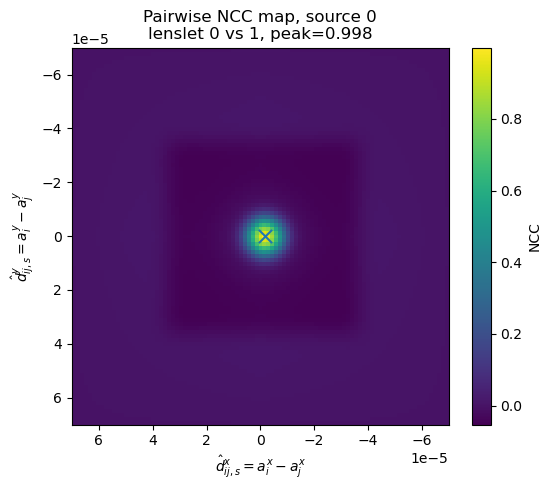

In [37]:
# Plot one pairwise NCC map with the peak marked.
example_ncc = pair_data["example_ncc"]
fig, ax = plt.subplots(figsize=(5.8, 5.0))

extent = [
    example_ncc["d_x_axis"][0],
    example_ncc["d_x_axis"][-1],
    example_ncc["d_y_axis"][0],
    example_ncc["d_y_axis"][-1],
]

im = ax.imshow(
    example_ncc["correlation"],
    origin="lower",
    extent=extent,
    aspect="equal",
)

ax.scatter(example_ncc["d_x"], example_ncc["d_y"], marker="x", s=90)
ax.set_xlabel(r"$\hat d^x_{ij,s}=a^x_i-a^x_j$")
ax.set_ylabel(r"$\hat d^y_{ij,s}=a^y_i-a^y_j$")
ax.set_title(
    f"Pairwise NCC map, source {example_ncc['source_id']}\n"
    f"lenslet {example_ncc['i']} vs {example_ncc['j']}, peak={example_ncc['peak']:.3f}"
)
plt.colorbar(im, ax=ax, fraction=0.046, label="NCC")
plt.tight_layout()
plt.show()

### 5.5 Graph Least-Squares Shift Reconstruction

All pairwise measurements for one source form a graph: lenslets are nodes and measured relative shifts are edges.

The unknown source-wise shifts are recovered by least squares under the zero-mean gauge constraint.

> **Why this is useful:** no single lenslet has to be declared a perfect reference. Information is distributed across many pairwise comparisons, making the estimate less dependent on one image tile.


In [38]:
def pairwise_confidence_weights(pair_peak, pair_sharpness):
    """Use NCC peak and peak sharpness as confidence weights."""
    peak_weight = np.clip(pair_peak, 0.0, None)
    if np.max(peak_weight) > 0:
        peak_weight = peak_weight / np.max(peak_weight)

    sharp_weight = np.clip(pair_sharpness, 0.0, None)
    if np.max(sharp_weight) > 0:
        sharp_weight = sharp_weight / np.max(sharp_weight)

    return np.sqrt(peak_weight * sharp_weight) + 1e-6


def solve_one_source_relative_shift(
    lenslet_ids,
    pair_i,
    pair_j,
    pair_dx,
    pair_dy,
    pair_weight,
):
    """Solve a_i - a_j = d_ij with sum_i a_i = 0 for one source."""
    lenslet_ids = np.array(lenslet_ids, dtype=int)
    local_id = {lenslet_id: k for k, lenslet_id in enumerate(lenslet_ids)}
    n = len(lenslet_ids)

    rows = []
    cols = []
    data = []
    bx = []
    by = []
    row_id = 0

    sqrt_weight = np.sqrt(pair_weight)

    for i, j, dx_ij, dy_ij, weight in zip(
        pair_i,
        pair_j,
        pair_dx,
        pair_dy,
        sqrt_weight,
    ):
        rows.extend([row_id, row_id])
        cols.extend([local_id[i], local_id[j]])
        data.extend([weight, -weight])
        bx.append(weight * dx_ij)
        by.append(weight * dy_ij)
        row_id += 1

    gauge_weight = 10.0 * np.median(sqrt_weight)
    if not np.isfinite(gauge_weight) or gauge_weight <= 0:
        gauge_weight = 1.0

    for lenslet_id in lenslet_ids:
        rows.append(row_id)
        cols.append(local_id[lenslet_id])
        data.append(gauge_weight / n)

    bx.append(0.0)
    by.append(0.0)
    row_id += 1

    A_shift = sparse.csr_matrix((data, (rows, cols)), shape=(row_id, n))
    solution_x = lsqr(A_shift, np.array(bx), atol=1e-11, btol=1e-11, iter_lim=2000)[0]
    solution_y = lsqr(A_shift, np.array(by), atol=1e-11, btol=1e-11, iter_lim=2000)[0]

    return lenslet_ids, solution_x, solution_y


def compute_pairwise_shift_residuals(pair_data, relative_shift):
    """Compare solved shifts with pairwise NCC measurements."""
    pair_i = pair_data["i"]
    pair_j = pair_data["j"]
    pair_s = pair_data["source_index"]

    predicted_x = relative_shift[pair_i, pair_s, 0] - relative_shift[pair_j, pair_s, 0]
    predicted_y = relative_shift[pair_i, pair_s, 1] - relative_shift[pair_j, pair_s, 1]

    residual_x = predicted_x - pair_data["dx_ij"]
    residual_y = predicted_y - pair_data["dy_ij"]

    return residual_x, residual_y


def solve_relative_shifts_least_squares(pair_data, valid_mask, source_info):
    """Solve source-wise relative shifts from pairwise NCC measurements."""
    n_lenslets_here, n_sources_used = valid_mask.shape
    relative_shift = np.full((n_lenslets_here, n_sources_used, 2), np.nan)
    source_solution_info = []

    pair_weight = pairwise_confidence_weights(
        pair_data["peak"],
        pair_data["peak_sharpness"],
    )

    for source_index in range(n_sources_used):
        source_pair_mask = pair_data["source_index"] == source_index
        lenslet_ids = np.where(valid_mask[:, source_index])[0]

        ids, solution_x, solution_y = solve_one_source_relative_shift(
            lenslet_ids=lenslet_ids,
            pair_i=pair_data["i"][source_pair_mask],
            pair_j=pair_data["j"][source_pair_mask],
            pair_dx=pair_data["dx_ij"][source_pair_mask],
            pair_dy=pair_data["dy_ij"][source_pair_mask],
            pair_weight=pair_weight[source_pair_mask],
        )

        relative_shift[ids, source_index, 0] = solution_x
        relative_shift[ids, source_index, 1] = solution_y

        source_solution_info.append({
            "source_index": source_index,
            "source_id": source_info[source_index]["source_id"],
            "n_lenslets": len(ids),
            "n_pairs": int(np.sum(source_pair_mask)),
            "mean_shift_x": np.nanmean(solution_x),
            "mean_shift_y": np.nanmean(solution_y),
        })

    residual_x, residual_y = compute_pairwise_shift_residuals(pair_data, relative_shift)

    pairwise_rmse_x = np.sqrt(np.average(residual_x**2, weights=pair_weight))
    pairwise_rmse_y = np.sqrt(np.average(residual_y**2, weights=pair_weight))
    pairwise_rmse_total = np.sqrt(
        np.average(residual_x**2 + residual_y**2, weights=pair_weight)
    )

    lenslet_confidence = np.zeros((n_lenslets_here, n_sources_used))
    lenslet_confidence_count = np.zeros((n_lenslets_here, n_sources_used))

    for i, j, s, weight in zip(
        pair_data["i"],
        pair_data["j"],
        pair_data["source_index"],
        pair_weight,
    ):
        lenslet_confidence[i, s] += weight
        lenslet_confidence[j, s] += weight
        lenslet_confidence_count[i, s] += 1
        lenslet_confidence_count[j, s] += 1

    lenslet_confidence = lenslet_confidence / np.maximum(lenslet_confidence_count, 1.0)

    return {
        "relative_shift": relative_shift,
        "pair_weight": pair_weight,
        "residual_x": residual_x,
        "residual_y": residual_y,
        "pairwise_rmse_x": pairwise_rmse_x,
        "pairwise_rmse_y": pairwise_rmse_y,
        "pairwise_rmse_total": pairwise_rmse_total,
        "lenslet_confidence": lenslet_confidence,
        "source_solution_info": source_solution_info,
    }


shift_solution = solve_relative_shifts_least_squares(
    pair_data,
    source_valid_mask,
    source_info,
)
estimated_relative_shift = shift_solution["relative_shift"]

print("Source-wise pairwise LS relative shift solution")
print(f"Pairwise shift RMSE x: {shift_solution['pairwise_rmse_x']:.3e}")
print(f"Pairwise shift RMSE y: {shift_solution['pairwise_rmse_y']:.3e}")
print(f"Pairwise shift RMSE total: {shift_solution['pairwise_rmse_total']:.3e}")
for info in shift_solution["source_solution_info"][:8]:
    print(
        f"Source {info['source_id']:2d}: pairs={info['n_pairs']}, "
        f"mean shift=({info['mean_shift_x']:.2e}, {info['mean_shift_y']:.2e})"
    )

Source-wise pairwise LS relative shift solution
Pairwise shift RMSE x: 4.107e-09
Pairwise shift RMSE y: 4.013e-09
Pairwise shift RMSE total: 5.742e-09
Source  0: pairs=350, mean shift=(2.00e-23, -3.51e-23)
Source  1: pairs=350, mean shift=(0.00e+00, 2.00e-23)
Source  2: pairs=350, mean shift=(-5.01e-24, -6.89e-24)
Source  3: pairs=350, mean shift=(2.51e-24, -6.01e-23)
Source  4: pairs=350, mean shift=(-5.01e-24, 5.01e-24)
Source  5: pairs=350, mean shift=(-5.01e-24, -7.52e-24)
Source  6: pairs=350, mean shift=(5.01e-24, -2.51e-23)
Source  7: pairs=350, mean shift=(2.00e-23, 5.01e-24)


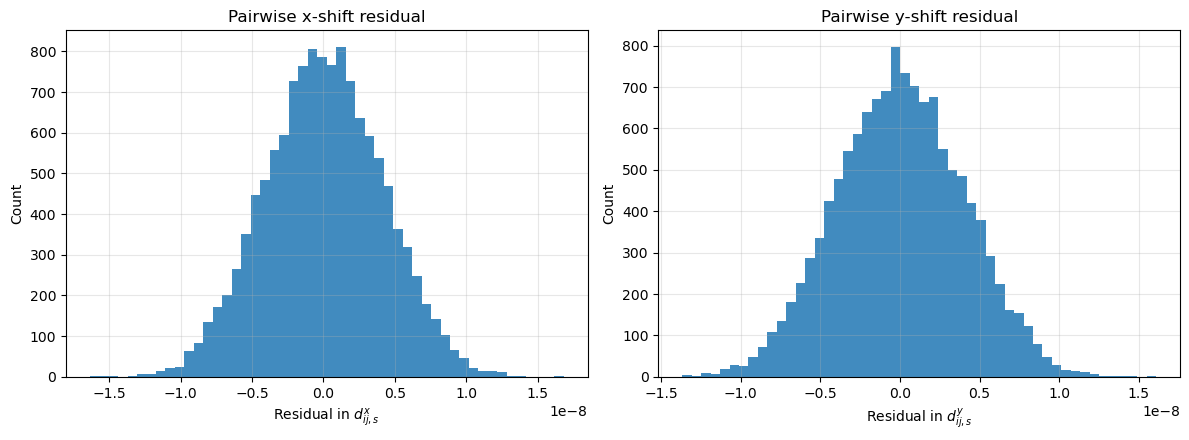

In [39]:
# Plot least-squares pairwise residuals.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(shift_solution["residual_x"], bins=50, alpha=0.85)
axes[0].set_xlabel(r"Residual in $d^x_{ij,s}$")
axes[0].set_ylabel("Count")
axes[0].set_title("Pairwise x-shift residual")
axes[0].grid(alpha=0.3)

axes[1].hist(shift_solution["residual_y"], bins=50, alpha=0.85)
axes[1].set_xlabel(r"Residual in $d^y_{ij,s}$")
axes[1].set_ylabel("Count")
axes[1].set_title("Pairwise y-shift residual")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 5.6 Relative Shift to Relative Tilt

The recovered detector shifts are converted into angular tilt using the microlens focal length:

$$\tau^{\mathrm{rel}}_{i,s}=\frac{a_{i,s}}{f_{\mathrm{ml}}}.$$

The result is still a **relative tilt**. Without an external reference, the source-wise common-mode tilt cannot be recovered.


In [40]:
def convert_shifts_to_tilts(relative_shift, f_lenslet, pixel_size=None, shift_units="physical"):
    """Convert relative detector shifts into relative local tilts."""
    if shift_units == "pixels":
        if pixel_size is None:
            raise ValueError("pixel_size is required when shift_units='pixels'.")
        physical_shift = relative_shift * pixel_size
    elif shift_units == "physical":
        physical_shift = relative_shift
    else:
        raise ValueError("shift_units must be either 'pixels' or 'physical'.")

    return physical_shift / f_lenslet


def build_source_tilt_measurements(
    estimated_relative_tilt,
    source_info,
    valid_mask,
    lenslet_centers_xy,
    lenslet_confidence,
):
    """Package source-level relative tilts for tomography."""
    measurements = []

    for source_index, source in enumerate(source_info):
        for lenslet_id, (x_lens, y_lens) in enumerate(lenslet_centers_xy):
            if not valid_mask[lenslet_id, source_index]:
                continue

            measurements.append({
                "source_index": source_index,
                "source_id": source["source_id"],
                "x_source": source["x_source"],
                "y_source": source["y_source"],
                "theta_x_source": source["theta_x"],
                "theta_y_source": source["theta_y"],
                "x_lens": x_lens,
                "y_lens": y_lens,
                "lenslet_id": lenslet_id,
                "flux": source["flux"],
                "ncc_peak": lenslet_confidence[lenslet_id, source_index],
                "theta_turbulence_est_x": estimated_relative_tilt[lenslet_id, source_index, 0],
                "theta_turbulence_est_y": estimated_relative_tilt[lenslet_id, source_index, 1],
                "shift_x_est": estimated_relative_shift[lenslet_id, source_index, 0],
                "shift_y_est": estimated_relative_shift[lenslet_id, source_index, 1],
            })

    return measurements


estimated_relative_tilt = convert_shifts_to_tilts(
    estimated_relative_shift,
    f_lenslet=f_ml,
    shift_units="physical",
)

tilt_measurements = build_source_tilt_measurements(
    estimated_relative_tilt,
    source_info,
    source_valid_mask,
    lenslet_centers_xy,
    shift_solution["lenslet_confidence"],
)

theta_meas_x_all = np.array([row["theta_turbulence_est_x"] for row in tilt_measurements])
theta_meas_y_all = np.array([row["theta_turbulence_est_y"] for row in tilt_measurements])

print("Source-wise relative tilt measurements")
print(f"Source-level measurements: {len(tilt_measurements)}")
print(f"x relative tilt std: {np.std(theta_meas_x_all):.3e} rad")
print(f"y relative tilt std: {np.std(theta_meas_y_all):.3e} rad")
print("Source-wise common-mode tilt is intentionally set to zero by the gauge constraint.")

Source-wise relative tilt measurements
Source-level measurements: 6084
x relative tilt std: 3.203e-06 rad
y relative tilt std: 3.016e-06 rad
Source-wise common-mode tilt is intentionally set to zero by the gauge constraint.


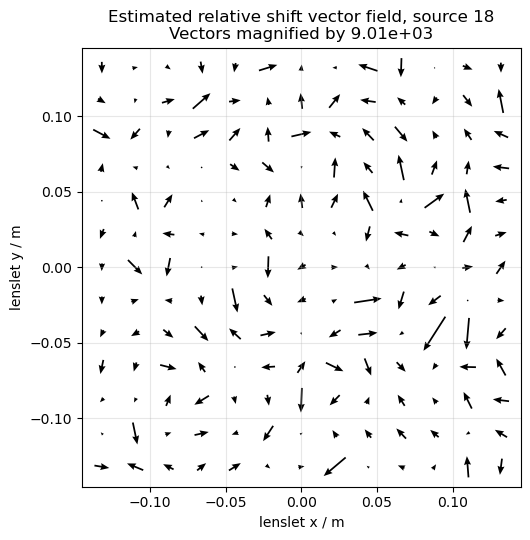

In [77]:
# Plot estimated relative shift vector field for one source.
source_for_shift_plot = len(source_info) // 2
source_for_shift_plot_id = source_info[source_for_shift_plot]["source_id"]

shift_x_map = estimated_relative_shift[:, source_for_shift_plot, 0].reshape(n_lenslets, n_lenslets)
shift_y_map = estimated_relative_shift[:, source_for_shift_plot, 1].reshape(n_lenslets, n_lenslets)

# Magnify the vectors only for visualisation.
shift_magnitude_map = np.hypot(shift_x_map, shift_y_map)
maximum_shift = np.nanmax(shift_magnitude_map)

# Make the longest arrow approximately 35% of one lenslet pitch.
target_arrow_length = 1.22* lenslet_pitch

if maximum_shift > 0:
    display_gain = target_arrow_length / maximum_shift
else:
    display_gain = 1.0

fig, ax = plt.subplots(figsize=(6, 5.5))

quiver_plot = ax.quiver(
    lenslet_x_grid,
    lenslet_y_grid,
    shift_x_map * display_gain,
    shift_y_map * display_gain,
    angles="xy",
    scale_units="xy",
    scale=1,
    pivot="mid",
    width=0.004,
    headwidth=4,
    headlength=5,
)

ax.set_xlabel("lenslet x / m")
ax.set_ylabel("lenslet y / m")
ax.set_title(
    f"Estimated relative shift vector field, source "
    f"{source_for_shift_plot_id}\n"
    f"Vectors magnified by {display_gain:.2e}"
)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

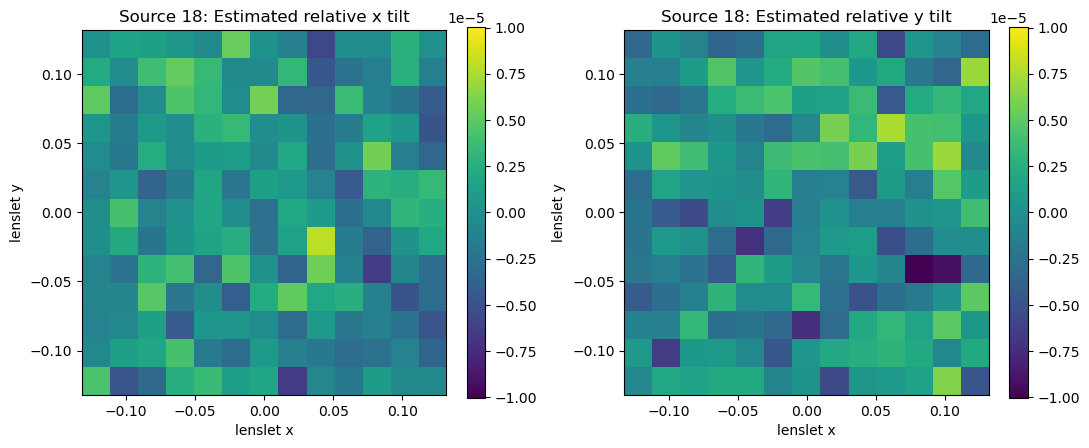

In [42]:
# Plot estimated relative tilt maps for one source.
source_for_tilt_map = len(source_info) // 2
source_for_tilt_map_id = source_info[source_for_tilt_map]["source_id"]

tilt_map_x = estimated_relative_tilt[:, source_for_tilt_map, 0].reshape(n_lenslets, n_lenslets)
tilt_map_y = estimated_relative_tilt[:, source_for_tilt_map, 1].reshape(n_lenslets, n_lenslets)

vmax_tilt = np.nanmax(np.abs([tilt_map_x, tilt_map_y]))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, panel, title in [
    (axes[0], tilt_map_x, "Estimated relative x tilt"),
    (axes[1], tilt_map_y, "Estimated relative y tilt"),
]:
    im = ax.imshow(
        panel,
        origin="lower",
        extent=[lenslet_axis[0], lenslet_axis[-1], lenslet_axis[0], lenslet_axis[-1]],
        aspect="equal",
        vmin=-vmax_tilt,
        vmax=vmax_tilt,
    )
    ax.set_title(f"Source {source_for_tilt_map_id}: {title}")
    ax.set_xlabel("lenslet x")
    ax.set_ylabel("lenslet y")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Diagnostic 1 — Relative Tilt Accuracy

Hidden true tilt is used here only for validation.

Because the estimator is source-wise relative, the true comparison quantity must also have its lenslet mean removed:

$$\theta_{\mathrm{true,rel},i,s}=\theta_{\mathrm{true},i,s}-\left\langle\theta_{\mathrm{true},i,s}\right\rangle_i.$$

This diagnostic answers a specific question:

**Did the image-registration stage correctly recover the relative wavefront slope before tomography is attempted?**


In [43]:
def safe_corrcoef(a, b):
    """Correlation coefficient with protection against zero-variance arrays."""
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()

    valid = np.isfinite(a) & np.isfinite(b)
    a = a[valid]
    b = b[valid]

    if len(a) < 3 or np.std(a) < 1e-14 or np.std(b) < 1e-14:
        return np.nan

    return np.corrcoef(a, b)[0, 1]


def compute_true_source_relative_tilts(
    tilt_measurements,
    rays_with_turbulence,
    flux_threshold,
):
    """Compute hidden true relative tilts for final validation only."""
    true_lookup = {
        (r["source_id"], r["lenslet_id"]): (
            r["theta_turbulence_x"],
            r["theta_turbulence_y"],
            r["flux"],
        )
        for r in rays_with_turbulence
        if r["flux"] >= flux_threshold
    }

    source_ids = sorted({row["source_id"] for row in tilt_measurements})
    source_mean_true_x = {}
    source_mean_true_y = {}

    for source_id in source_ids:
        tx = []
        ty = []
        for lenslet_id in range(n_lenslet_total):
            tx_true, ty_true, _ = true_lookup[(source_id, lenslet_id)]
            tx.append(tx_true)
            ty.append(ty_true)

        source_mean_true_x[source_id] = np.mean(tx)
        source_mean_true_y[source_id] = np.mean(ty)

    true_relative_x = []
    true_relative_y = []
    estimated_relative_x = []
    estimated_relative_y = []

    for row in tilt_measurements:
        source_id = row["source_id"]
        lenslet_id = row["lenslet_id"]
        tx_true, ty_true, _ = true_lookup[(source_id, lenslet_id)]

        true_relative_x.append(tx_true - source_mean_true_x[source_id])
        true_relative_y.append(ty_true - source_mean_true_y[source_id])
        estimated_relative_x.append(row["theta_turbulence_est_x"])
        estimated_relative_y.append(row["theta_turbulence_est_y"])

    return (
        np.array(true_relative_x),
        np.array(true_relative_y),
        np.array(estimated_relative_x),
        np.array(estimated_relative_y),
    )


(
    true_relative_tilts_x,
    true_relative_tilts_y,
    estimated_relative_tilts_x,
    estimated_relative_tilts_y,
) = compute_true_source_relative_tilts(
    tilt_measurements,
    rays_with_turbulence,
    flux_threshold_for_tilt,
)

tilt_errors_x = estimated_relative_tilts_x - true_relative_tilts_x
tilt_errors_y = estimated_relative_tilts_y - true_relative_tilts_y

tilt_rmse_x = np.sqrt(np.mean(tilt_errors_x**2))
tilt_rmse_y = np.sqrt(np.mean(tilt_errors_y**2))

tilt_corr_x = safe_corrcoef(estimated_relative_tilts_x, true_relative_tilts_x)
tilt_corr_y = safe_corrcoef(estimated_relative_tilts_y, true_relative_tilts_y)

print("Diagnostic 1: source-wise relative tilt validation")
print(f"x relative tilt corr: {tilt_corr_x:.3f}")
print(f"y relative tilt corr: {tilt_corr_y:.3f}")
print(f"x relative tilt RMSE: {tilt_rmse_x:.3e} rad")
print(f"y relative tilt RMSE: {tilt_rmse_y:.3e} rad")
print(f"x relative tilt std:  {np.std(estimated_relative_tilts_x):.3e} rad")
print(f"y relative tilt std:  {np.std(estimated_relative_tilts_y):.3e} rad")

Diagnostic 1: source-wise relative tilt validation
x relative tilt corr: 1.000
y relative tilt corr: 1.000
x relative tilt RMSE: 2.077e-07 rad
y relative tilt RMSE: 1.964e-07 rad
x relative tilt std:  3.203e-06 rad
y relative tilt std:  3.016e-06 rad


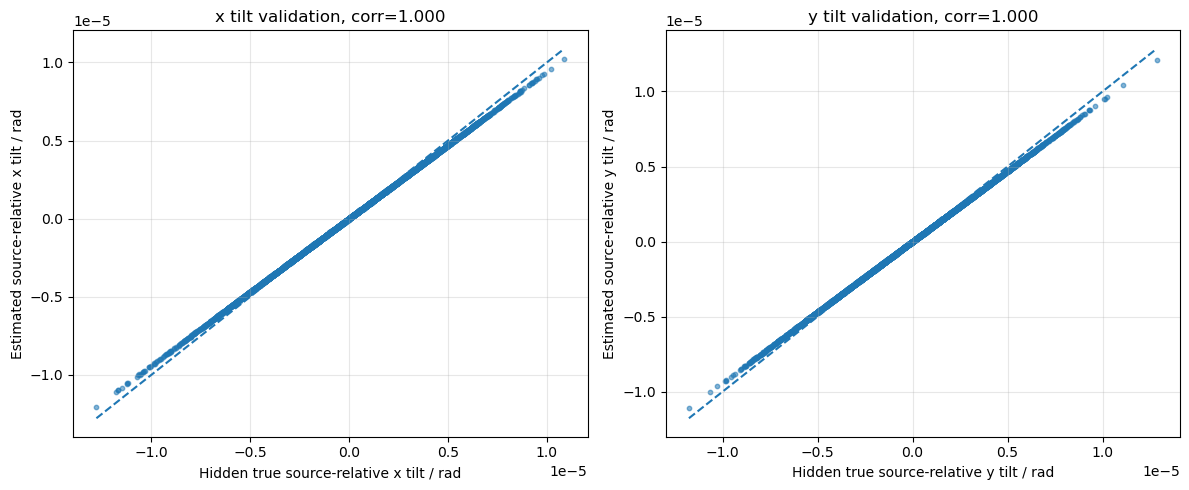

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    true_relative_tilts_x,
    estimated_relative_tilts_x,
    s=10,
    alpha=0.55,
)
line_min = min(true_relative_tilts_x.min(), estimated_relative_tilts_x.min())
line_max = max(true_relative_tilts_x.max(), estimated_relative_tilts_x.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "--")
axes[0].set_xlabel("Hidden true source-relative x tilt / rad")
axes[0].set_ylabel("Estimated source-relative x tilt / rad")
axes[0].set_title(f"x tilt validation, corr={tilt_corr_x:.3f}")
axes[0].grid(alpha=0.3)

axes[1].scatter(
    true_relative_tilts_y,
    estimated_relative_tilts_y,
    s=10,
    alpha=0.55,
)
line_min = min(true_relative_tilts_y.min(), estimated_relative_tilts_y.min())
line_max = max(true_relative_tilts_y.max(), estimated_relative_tilts_y.max())
axes[1].plot([line_min, line_max], [line_min, line_max], "--")
axes[1].set_xlabel("Hidden true source-relative y tilt / rad")
axes[1].set_ylabel("Estimated source-relative y tilt / rad")
axes[1].set_title(f"y tilt validation, corr={tilt_corr_y:.3f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Coarse-to-Fine Two-Layer Tomography

This is the main reconstruction update in v2.5.3.

A fine-grid inversion can reproduce the measured total tilt while incorrectly exchanging spatial structure between the two layers. Therefore, the reconstruction is performed in two stages:

1. **Coarse solve:** recover stable large-scale layer separation.
2. **Fine solve:** recover additional spatial detail while remaining close to the interpolated coarse solution.

The fine solve minimises

$$\|W_m(Ax-b)\|^2+\lambda_g^2\|Gx\|^2+\lambda_c^2\|Lx\|^2+\lambda_r^2\|x\|^2+\lambda_p^2\|x-x_{\mathrm{coarse}}\|^2.$$

Here:

- $W_m$ weights measurements by confidence,
- $G$ penalises large first differences,
- $L$ penalises curvature,
- the ridge term limits unstable amplitudes,
- $x_{\mathrm{coarse}}$ provides a data-derived coarse prior.

> **Key update:** the prior contains no hidden truth. It comes only from the coarse reconstruction.

> **Main difficulty — layer swapping:** two different layer decompositions can produce nearly the same summed measurement. Therefore, a small forward residual alone is not enough to prove that the individual layers are correct.

> **General inverse-problem lesson:** improving resolution increases the number of unknowns and can reduce identifiability. A coarser intermediate solution can sometimes make a later fine reconstruction more reliable.


In [45]:
def interpolation_weights_2d(x_grid, y_grid, x, y):
    """Bilinear interpolation weights for a 2D grid."""
    if x <= x_grid[0]:
        i0 = 0
        wx = 0.0
    elif x >= x_grid[-1]:
        i0 = len(x_grid) - 2
        wx = 1.0
    else:
        i0 = np.searchsorted(x_grid, x) - 1
        wx = (x - x_grid[i0]) / (x_grid[i0 + 1] - x_grid[i0])

    if y <= y_grid[0]:
        j0 = 0
        wy = 0.0
    elif y >= y_grid[-1]:
        j0 = len(y_grid) - 2
        wy = 1.0
    else:
        j0 = np.searchsorted(y_grid, y) - 1
        wy = (y - y_grid[j0]) / (y_grid[j0 + 1] - y_grid[j0])

    weights = []

    for dj, wy_part in [(0, 1.0 - wy), (1, wy)]:
        for di, wx_part in [(0, 1.0 - wx), (1, wx)]:
            i = i0 + di
            j = j0 + dj
            flat_id = j * len(x_grid) + i
            weights.append((flat_id, wx_part * wy_part))

    return weights


In [46]:
def build_layer_grids_from_measurements(
    tilt_measurements,
    turbulent_layers,
    n_layer_grid,
):
    """Build one reconstruction grid for each turbulent layer.

    Each measurement row represents one lenslet and one individual source.
    The full 2D source coordinate is used for ray-layer hits.
    """
    layer_grids = []

    for layer in turbulent_layers:
        hits_x = []
        hits_y = []

        for row in tilt_measurements:
            x_hit, y_hit = xy_at_layer(
                row["x_source"],
                row["y_source"],
                row["x_lens"],
                row["y_lens"],
                layer["z"],
            )

            hits_x.append(x_hit)
            hits_y.append(y_hit)

        extent = max(np.max(np.abs(hits_x)), np.max(np.abs(hits_y)))
        extent += 0.5 * lenslet_pitch

        x_grid = np.linspace(-extent, extent, n_layer_grid)
        y_grid = np.linspace(-extent, extent, n_layer_grid)

        layer_grids.append((x_grid, y_grid))

    return layer_grids

In [47]:
def measurement_confidence_weight(row, max_flux_used, max_peak_used):
    """Weight one tilt measurement from source flux and NCC peak."""
    flux_weight = np.sqrt(row["flux"] / max_flux_used)
    peak_weight = np.sqrt(max(row["ncc_peak"], 0.0) / (max_peak_used + 1e-12))

    return flux_weight * peak_weight


In [48]:
def subtract_source_common_mode_from_matrix(A, source_indices):
    """Subtract each source group's mean model row from A.

    This implements the fact that measured tilts are relative within each
    individual source and have zero source-wise mean by construction.
    """
    A_dense = A.toarray()

    for source_index in np.unique(source_indices):
        row_ids = np.where(source_indices == source_index)[0]
        A_dense[row_ids] -= np.mean(A_dense[row_ids], axis=0, keepdims=True)

    return sparse.csr_matrix(A_dense)


def build_layer_support_masks(A_raw, n_layer_grid, n_layers, support_threshold=0.05):
    """Estimate reconstruction support from tomography matrix column norms."""
    n_grid_per_layer = n_layer_grid * n_layer_grid
    column_norm = np.sqrt(np.asarray(A_raw.power(2).sum(axis=0)).ravel())

    support_masks = []
    support_strengths = []

    for layer_id in range(n_layers):
        start = layer_id * n_grid_per_layer
        stop = start + n_grid_per_layer
        layer_norm = column_norm[start:stop]

        if np.max(layer_norm) > 0:
            strength = layer_norm / np.max(layer_norm)
        else:
            strength = np.zeros_like(layer_norm)

        support_strengths.append(strength.reshape(n_layer_grid, n_layer_grid))
        support_masks.append((strength >= support_threshold).reshape(n_layer_grid, n_layer_grid))

    return support_masks, support_strengths


def build_tomography_matrix(
    tilt_measurements,
    turbulent_layers,
    layer_grids,
    n_layer_grid,
    support_threshold=0.05,
):
    """Build b = A x for the source-level two-layer slope reconstruction."""
    n_grid_per_layer = n_layer_grid * n_layer_grid
    n_unknowns = len(turbulent_layers) * n_grid_per_layer

    A_row_ids = []
    A_col_ids = []
    A_data = []
    b_x_values = []
    b_y_values = []
    measurement_weights = []
    source_indices = []

    max_flux_used = max(row["flux"] for row in tilt_measurements)
    max_peak_used = max(max(row["ncc_peak"], 0.0) for row in tilt_measurements)

    for measurement_id, row in enumerate(tilt_measurements):
        for layer_id, layer in enumerate(turbulent_layers):
            x_hit, y_hit = xy_at_layer(
                row["x_source"],
                row["y_source"],
                row["x_lens"],
                row["y_lens"],
                layer["z"],
            )

            x_grid, y_grid = layer_grids[layer_id]
            offset = layer_id * n_grid_per_layer

            for flat_id, weight in interpolation_weights_2d(x_grid, y_grid, x_hit, y_hit):
                A_row_ids.append(measurement_id)
                A_col_ids.append(offset + flat_id)
                A_data.append(weight)

        b_x_values.append(row["theta_turbulence_est_x"])
        b_y_values.append(row["theta_turbulence_est_y"])
        source_indices.append(row["source_index"])
        measurement_weights.append(
            measurement_confidence_weight(row, max_flux_used, max_peak_used)
        )

    A_raw = sparse.csr_matrix(
        (A_data, (A_row_ids, A_col_ids)),
        shape=(len(tilt_measurements), n_unknowns),
    )

    source_indices = np.array(source_indices, dtype=int)
    A = subtract_source_common_mode_from_matrix(A_raw, source_indices)

    support_masks, support_strengths = build_layer_support_masks(
        A_raw,
        n_layer_grid=n_layer_grid,
        n_layers=len(turbulent_layers),
        support_threshold=support_threshold,
    )

    return (
        A,
        A_raw,
        np.array(b_x_values),
        np.array(b_y_values),
        np.array(measurement_weights),
        source_indices,
        support_masks,
        support_strengths,
    )

In [49]:
def append_gradient_terms(
    reg_row_ids,
    reg_col_ids,
    reg_data,
    reg_values,
    reg_row,
    layer_id,
    n_layer_grid,
    n_grid_per_layer,
    lambda_gradient,
):
    """Append first-neighbour gradient regularisation for one layer."""
    if lambda_gradient <= 0:
        return reg_row

    offset = layer_id * n_grid_per_layer

    # Horizontal first differences.
    for j in range(n_layer_grid):
        for i in range(n_layer_grid - 1):
            left = offset + j * n_layer_grid + i
            right = left + 1
            reg_row_ids.extend([reg_row, reg_row])
            reg_col_ids.extend([left, right])
            reg_data.extend([-lambda_gradient, lambda_gradient])
            reg_values.append(0.0)
            reg_row += 1

    # Vertical first differences.
    for j in range(n_layer_grid - 1):
        for i in range(n_layer_grid):
            lower = offset + j * n_layer_grid + i
            upper = offset + (j + 1) * n_layer_grid + i
            reg_row_ids.extend([reg_row, reg_row])
            reg_col_ids.extend([lower, upper])
            reg_data.extend([-lambda_gradient, lambda_gradient])
            reg_values.append(0.0)
            reg_row += 1

    return reg_row


def append_curvature_terms(
    reg_row_ids,
    reg_col_ids,
    reg_data,
    reg_values,
    reg_row,
    layer_id,
    n_layer_grid,
    n_grid_per_layer,
    lambda_curvature,
):
    """Append five-point Laplacian regularisation for one layer."""
    if lambda_curvature <= 0:
        return reg_row

    offset = layer_id * n_grid_per_layer

    for j in range(1, n_layer_grid - 1):
        for i in range(1, n_layer_grid - 1):
            centre = offset + j * n_layer_grid + i
            neighbours = [
                (centre, -4.0),
                (offset + j * n_layer_grid + i - 1, 1.0),
                (offset + j * n_layer_grid + i + 1, 1.0),
                (offset + (j - 1) * n_layer_grid + i, 1.0),
                (offset + (j + 1) * n_layer_grid + i, 1.0),
            ]

            for col_id, value in neighbours:
                reg_row_ids.append(reg_row)
                reg_col_ids.append(col_id)
                reg_data.append(lambda_curvature * value)

            reg_values.append(0.0)
            reg_row += 1

    return reg_row

In [50]:
def append_mean_constraint(
    reg_row_ids,
    reg_col_ids,
    reg_data,
    reg_values,
    reg_row,
    layer_id,
    n_grid_per_layer,
    lambda_mean,
):
    """Append a weak zero-mean gauge constraint for one layer."""
    if lambda_mean <= 0:
        return reg_row

    offset = layer_id * n_grid_per_layer
    coefficient = lambda_mean / n_grid_per_layer

    for flat_id in range(n_grid_per_layer):
        reg_row_ids.append(reg_row)
        reg_col_ids.append(offset + flat_id)
        reg_data.append(coefficient)

    reg_values.append(0.0)
    return reg_row + 1


def append_ridge_terms(
    reg_row_ids,
    reg_col_ids,
    reg_data,
    reg_values,
    reg_row,
    n_unknowns,
    lambda_ridge,
):
    """Append weak Tikhonov ridge equations."""
    if lambda_ridge <= 0:
        return reg_row

    for unknown_id in range(n_unknowns):
        reg_row_ids.append(reg_row)
        reg_col_ids.append(unknown_id)
        reg_data.append(lambda_ridge)
        reg_values.append(0.0)
        reg_row += 1

    return reg_row


def append_prior_terms(
    reg_row_ids,
    reg_col_ids,
    reg_data,
    reg_values,
    reg_row,
    prior_solution,
    lambda_prior,
):
    """Append a weak diagonal prior towards an interpolated coarse solution."""
    if prior_solution is None or lambda_prior <= 0:
        return reg_row

    prior_solution = np.asarray(prior_solution, dtype=float).ravel()

    for unknown_id, prior_value in enumerate(prior_solution):
        reg_row_ids.append(reg_row)
        reg_col_ids.append(unknown_id)
        reg_data.append(lambda_prior)
        reg_values.append(lambda_prior * prior_value)
        reg_row += 1

    return reg_row

In [51]:
def build_regularization_matrix_v252(
    n_layer_grid,
    n_layers,
    lambda_gradient,
    lambda_curvature,
    lambda_ridge,
    lambda_mean,
    prior_solution=None,
    lambda_prior=0.0,
):
    """Build the v2.5.3 gradient, curvature, gauge, ridge, and prior terms."""
    n_grid_per_layer = n_layer_grid * n_layer_grid
    n_unknowns = n_layers * n_grid_per_layer

    reg_row_ids, reg_col_ids, reg_data, reg_values = [], [], [], []
    reg_row = 0

    for layer_id in range(n_layers):
        reg_row = append_gradient_terms(
            reg_row_ids,
            reg_col_ids,
            reg_data,
            reg_values,
            reg_row,
            layer_id,
            n_layer_grid,
            n_grid_per_layer,
            lambda_gradient,
        )
        reg_row = append_curvature_terms(
            reg_row_ids,
            reg_col_ids,
            reg_data,
            reg_values,
            reg_row,
            layer_id,
            n_layer_grid,
            n_grid_per_layer,
            lambda_curvature,
        )
        reg_row = append_mean_constraint(
            reg_row_ids,
            reg_col_ids,
            reg_data,
            reg_values,
            reg_row,
            layer_id,
            n_grid_per_layer,
            lambda_mean,
        )

    reg_row = append_ridge_terms(
        reg_row_ids,
        reg_col_ids,
        reg_data,
        reg_values,
        reg_row,
        n_unknowns,
        lambda_ridge,
    )
    reg_row = append_prior_terms(
        reg_row_ids,
        reg_col_ids,
        reg_data,
        reg_values,
        reg_row,
        prior_solution,
        lambda_prior,
    )

    R = sparse.csr_matrix(
        (reg_data, (reg_row_ids, reg_col_ids)),
        shape=(reg_row, n_unknowns),
    )
    return R, np.asarray(reg_values, dtype=float)

In [52]:
def solve_regularized_component(A_augmented, b_augmented):
    """Solve one sparse regularised least-squares component."""
    return lsqr(
        A_augmented,
        b_augmented,
        atol=1e-10,
        btol=1e-10,
        iter_lim=3000,
    )


def resample_component_solution(
    solution,
    old_layer_grids,
    old_n,
    new_layer_grids,
    new_n,
    n_layers,
):
    """Interpolate a stacked coarse layer solution onto the fine grids."""
    old_n_per_layer = old_n * old_n
    resampled_fields = []

    for layer_id in range(n_layers):
        start = layer_id * old_n_per_layer
        field_old = np.asarray(
            solution[start:start + old_n_per_layer]
        ).reshape(old_n, old_n)

        x_old, y_old = old_layer_grids[layer_id]
        x_new, y_new = new_layer_grids[layer_id]
        X_new, Y_new = np.meshgrid(x_new, y_new, indexing="xy")

        field_new = interp2_uniform(
            x_old,
            y_old,
            field_old,
            X_new,
            Y_new,
        )
        resampled_fields.append(np.asarray(field_new).reshape(new_n, new_n).ravel())

    return np.concatenate(resampled_fields)

In [53]:
def package_tomography_result_v252(
    A,
    A_raw,
    b_x,
    b_y,
    measurement_weights,
    source_indices,
    layer_grids,
    n_layer_grid,
    support_masks,
    support_strengths,
    support_threshold,
    regularisation,
    solutions,
    lsqr_results,
    coarse_result=None,
):
    """Collect v2.5.3 tomography outputs in one dictionary."""
    solution_x, solution_y = solutions
    model_tilt_x = A @ solution_x
    model_tilt_y = A @ solution_y

    result = {
        "A": A,
        "A_raw": A_raw,
        "b_x": b_x,
        "b_y": b_y,
        "measurement_weights": measurement_weights,
        "source_indices": source_indices,
        "layer_grids": layer_grids,
        "n_layer_grid": n_layer_grid,
        "n_grid_per_layer": n_layer_grid * n_layer_grid,
        "n_unknowns": A.shape[1],
        "support_masks": support_masks,
        "support_strengths": support_strengths,
        "support_threshold": support_threshold,
        "solution_x": solution_x,
        "solution_y": solution_y,
        "model_tilt_x": model_tilt_x,
        "model_tilt_y": model_tilt_y,
        "measurement_fit_rmse_x": np.sqrt(np.mean((model_tilt_x - b_x) ** 2)),
        "measurement_fit_rmse_y": np.sqrt(np.mean((model_tilt_y - b_y) ** 2)),
        "lsqr_x": lsqr_results[0],
        "lsqr_y": lsqr_results[1],
        "coarse_result": coarse_result,
    }
    result.update(regularisation)

    # Backward-compatible alias used by some later diagnostic text.
    result["lambda_smooth"] = regularisation["lambda_curvature"]
    return result

In [54]:
def reconstruct_two_layers_single_scale_v252(
    tilt_measurements,
    turbulent_layers,
    n_layer_grid,
    lambda_gradient,
    lambda_curvature,
    lambda_ridge,
    lambda_mean,
    support_threshold,
    prior_x=None,
    prior_y=None,
    lambda_prior=0.0,
    coarse_result=None,
):
    """Solve one tomography scale without using hidden truth."""
    layer_grids = build_layer_grids_from_measurements(
        tilt_measurements,
        turbulent_layers,
        n_layer_grid,
    )
    (
        A,
        A_raw,
        b_x,
        b_y,
        weights,
        source_indices,
        support_masks,
        support_strengths,
    ) = build_tomography_matrix(
        tilt_measurements,
        turbulent_layers,
        layer_grids,
        n_layer_grid,
        support_threshold=support_threshold,
    )

    common_kwargs = dict(
        n_layer_grid=n_layer_grid,
        n_layers=len(turbulent_layers),
        lambda_gradient=lambda_gradient,
        lambda_curvature=lambda_curvature,
        lambda_ridge=lambda_ridge,
        lambda_mean=lambda_mean,
        lambda_prior=lambda_prior,
    )
    R_x, regularisation_values_x = build_regularization_matrix_v252(
        prior_solution=prior_x,
        **common_kwargs,
    )
    R_y, regularisation_values_y = build_regularization_matrix_v252(
        prior_solution=prior_y,
        **common_kwargs,
    )

    A_weighted = A.multiply(weights[:, None])
    A_augmented_x = sparse.vstack([A_weighted, R_x], format="csr")
    A_augmented_y = sparse.vstack([A_weighted, R_y], format="csr")
    b_x_augmented = np.concatenate([b_x * weights, regularisation_values_x])
    b_y_augmented = np.concatenate([b_y * weights, regularisation_values_y])

    lsqr_x = solve_regularized_component(A_augmented_x, b_x_augmented)
    lsqr_y = solve_regularized_component(A_augmented_y, b_y_augmented)

    regularisation = {
        "lambda_gradient": lambda_gradient,
        "lambda_curvature": lambda_curvature,
        "lambda_ridge": lambda_ridge,
        "lambda_mean": lambda_mean,
        "lambda_prior": lambda_prior,
    }

    return package_tomography_result_v252(
        A=A,
        A_raw=A_raw,
        b_x=b_x,
        b_y=b_y,
        measurement_weights=weights,
        source_indices=source_indices,
        layer_grids=layer_grids,
        n_layer_grid=n_layer_grid,
        support_masks=support_masks,
        support_strengths=support_strengths,
        support_threshold=support_threshold,
        regularisation=regularisation,
        solutions=(lsqr_x[0], lsqr_y[0]),
        lsqr_results=(lsqr_x, lsqr_y),
        coarse_result=coarse_result,
    )


def reconstruct_two_layers_coarse_to_fine_v252(
    tilt_measurements,
    turbulent_layers,
    coarse_n=13,
    fine_n=17,
    coarse_parameters=None,
    fine_parameters=None,
):
    """Stable two-stage tomography for complex Kolmogorov layers."""
    if coarse_parameters is None:
        coarse_parameters = {
            "lambda_gradient": 0.12,
            "lambda_curvature": 0.38,
            "lambda_ridge": 0.015,
            "lambda_mean": 1.0,
            "support_threshold": 0.08,
        }
    if fine_parameters is None:
        fine_parameters = {
            "lambda_gradient": 0.06,
            "lambda_curvature": 0.16,
            "lambda_ridge": 0.008,
            "lambda_mean": 1.0,
            "lambda_prior": 0.10,
            "support_threshold": 0.10,
        }

    coarse_result = reconstruct_two_layers_single_scale_v252(
        tilt_measurements=tilt_measurements,
        turbulent_layers=turbulent_layers,
        n_layer_grid=coarse_n,
        lambda_prior=0.0,
        **coarse_parameters,
    )

    fine_layer_grids = build_layer_grids_from_measurements(
        tilt_measurements,
        turbulent_layers,
        fine_n,
    )
    prior_x = resample_component_solution(
        coarse_result["solution_x"],
        coarse_result["layer_grids"],
        coarse_n,
        fine_layer_grids,
        fine_n,
        len(turbulent_layers),
    )
    prior_y = resample_component_solution(
        coarse_result["solution_y"],
        coarse_result["layer_grids"],
        coarse_n,
        fine_layer_grids,
        fine_n,
        len(turbulent_layers),
    )

    return reconstruct_two_layers_single_scale_v252(
        tilt_measurements=tilt_measurements,
        turbulent_layers=turbulent_layers,
        n_layer_grid=fine_n,
        prior_x=prior_x,
        prior_y=prior_y,
        coarse_result=coarse_result,
        **fine_parameters,
    )

In [55]:
def forward_check_total_tilt(A, solution_x, solution_y):
    """Predict total measured tilt from reconstructed layers."""
    return A @ solution_x, A @ solution_y


In [56]:
def extract_layer_solution_fields(tomography_result, layer_id):
    """Extract estimated x/y slope maps for one reconstructed layer."""
    n_layer_grid = tomography_result["n_layer_grid"]
    n_grid_per_layer = tomography_result["n_grid_per_layer"]
    offset = layer_id * n_grid_per_layer

    tx_est = tomography_result["solution_x"][
        offset:offset + n_grid_per_layer
    ].reshape(n_layer_grid, n_layer_grid)

    ty_est = tomography_result["solution_y"][
        offset:offset + n_grid_per_layer
    ].reshape(n_layer_grid, n_layer_grid)

    return tx_est, ty_est


In [57]:
def masked_zero_mean(values, mask):
    """Remove the mean over supported finite samples only."""
    out = np.array(values, dtype=float, copy=True)
    valid = mask & np.isfinite(out)
    out = out - np.mean(out[valid])
    return out


def masked_rmse(a, b, mask):
    valid = mask & np.isfinite(a) & np.isfinite(b)
    return np.sqrt(np.mean((a[valid] - b[valid])**2))


def validate_layer_slopes_against_hidden_truth(
    tomography_result,
    turbulent_layers,
):
    """Validate estimated layer slopes against the hidden simulation truth."""
    layer_metrics = []

    for layer_id, layer in enumerate(turbulent_layers):
        x_grid, y_grid = tomography_result["layer_grids"][layer_id]
        X_est, Y_est = np.meshgrid(x_grid, y_grid, indexing="xy")

        tx_est, ty_est = extract_layer_solution_fields(tomography_result, layer_id)
        tx_true = layer_tilt_x(layer, X_est, Y_est)
        ty_true = layer_tilt_y(layer, X_est, Y_est)

        support_mask = tomography_result["support_masks"][layer_id]
        support_strength = tomography_result["support_strengths"][layer_id]

        tx_est_zero_mean = masked_zero_mean(tx_est, support_mask)
        ty_est_zero_mean = masked_zero_mean(ty_est, support_mask)
        tx_true_zero_mean = masked_zero_mean(tx_true, support_mask)
        ty_true_zero_mean = masked_zero_mean(ty_true, support_mask)

        layer_metrics.append({
            "layer_id": layer_id,
            "name": layer["name"],
            "x_grid": x_grid,
            "y_grid": y_grid,
            "support_mask": support_mask,
            "support_strength": support_strength,
            "support_fraction": np.mean(support_mask),
            "tx_est": tx_est,
            "ty_est": ty_est,
            "tx_true": tx_true,
            "ty_true": ty_true,
            "tx_rmse": masked_rmse(tx_est_zero_mean, tx_true_zero_mean, support_mask),
            "ty_rmse": masked_rmse(ty_est_zero_mean, ty_true_zero_mean, support_mask),
            "tx_corr": safe_corrcoef(tx_est_zero_mean[support_mask], tx_true_zero_mean[support_mask]),
            "ty_corr": safe_corrcoef(ty_est_zero_mean[support_mask], ty_true_zero_mean[support_mask]),
        })

    return layer_metrics

In [58]:
# v2.5.3 fixed parameters: no hidden truth is used for selecting the solution.
coarse_parameters_v252 = {
    "lambda_gradient": 0.12,
    "lambda_curvature": 0.38,
    "lambda_ridge": 0.015,
    "lambda_mean": 1.0,
    "support_threshold": 0.08,
}

fine_parameters_v252 = {
    "lambda_gradient": 0.06,
    "lambda_curvature": 0.16,
    "lambda_ridge": 0.008,
    "lambda_mean": 1.0,
    "lambda_prior": 0.10,
    "support_threshold": 0.10,
}

tomography_result = reconstruct_two_layers_coarse_to_fine_v252(
    tilt_measurements=tilt_measurements,
    turbulent_layers=turbulent_layers,
    coarse_n=13,
    fine_n=17,
    coarse_parameters=coarse_parameters_v252,
    fine_parameters=fine_parameters_v252,
)

A = tomography_result["A"]
A_raw = tomography_result["A_raw"]
b_x = tomography_result["b_x"]
b_y = tomography_result["b_y"]
measurement_weights = tomography_result["measurement_weights"]
source_indices = tomography_result["source_indices"]
layer_grids = tomography_result["layer_grids"]
n_layer_grid = tomography_result["n_layer_grid"]
n_grid_per_layer = tomography_result["n_grid_per_layer"]
n_unknowns = tomography_result["n_unknowns"]
support_masks = tomography_result["support_masks"]
support_strengths = tomography_result["support_strengths"]
support_threshold = tomography_result["support_threshold"]

lambda_gradient = tomography_result["lambda_gradient"]
lambda_curvature = tomography_result["lambda_curvature"]
lambda_smooth = tomography_result["lambda_smooth"]
lambda_ridge = tomography_result["lambda_ridge"]
lambda_mean = tomography_result["lambda_mean"]
lambda_prior = tomography_result["lambda_prior"]

solution_x = tomography_result["solution_x"]
solution_y = tomography_result["solution_y"]
model_tilt_x = tomography_result["model_tilt_x"]
model_tilt_y = tomography_result["model_tilt_y"]
measurement_fit_rmse_x = tomography_result["measurement_fit_rmse_x"]
measurement_fit_rmse_y = tomography_result["measurement_fit_rmse_y"]

In [59]:
layer_metrics = validate_layer_slopes_against_hidden_truth(
    tomography_result,
    turbulent_layers,
)

coarse_result = tomography_result["coarse_result"]
print("Final v2.5.3 coarse-to-fine tomography solution")
print(f"Coarse grid: {coarse_result['n_layer_grid']} x {coarse_result['n_layer_grid']}")
print(f"Fine grid: {n_layer_grid} x {n_layer_grid}")
print(f"Measurements used: {A.shape[0]}")
print(f"Unknown slope samples per component: {A.shape[1]}")
print(f"Gradient lambda: {lambda_gradient}")
print(f"Curvature lambda: {lambda_curvature}")
print(f"Ridge lambda: {lambda_ridge}")
print(f"Coarse-prior lambda: {lambda_prior}")
print(f"Mean-gauge lambda: {lambda_mean}")
print(f"Support threshold: {support_threshold}")
print(f"fit_RMSE_x: {measurement_fit_rmse_x:.3e} rad")
print(f"fit_RMSE_y: {measurement_fit_rmse_y:.3e} rad")
print()

for metric in layer_metrics:
    layer = turbulent_layers[metric["layer_id"]]

    layer["estimation_x_grid"] = metric["x_grid"]
    layer["estimation_y_grid"] = metric["y_grid"]
    layer["support_mask"] = metric["support_mask"]
    layer["support_strength"] = metric["support_strength"]
    layer["support_fraction"] = metric["support_fraction"]
    layer["estimated_tilt_x"] = metric["tx_est"]
    layer["estimated_tilt_y"] = metric["ty_est"]
    layer["true_tilt_x_on_grid"] = metric["tx_true"]
    layer["true_tilt_y_on_grid"] = metric["ty_true"]
    layer["tilt_x_rmse"] = metric["tx_rmse"]
    layer["tilt_y_rmse"] = metric["ty_rmse"]
    layer["tilt_x_corr"] = metric["tx_corr"]
    layer["tilt_y_corr"] = metric["ty_corr"]

    print(
        f"{layer['name']}: "
        f"support = {100 * metric['support_fraction']:.1f}%, "
        f"x slope RMSE = {metric['tx_rmse']:.3e}, corr = {metric['tx_corr']:.3f}; "
        f"y slope RMSE = {metric['ty_rmse']:.3e}, corr = {metric['ty_corr']:.3f}"
    )

Final v2.5.3 coarse-to-fine tomography solution
Coarse grid: 13 x 13
Fine grid: 17 x 17
Measurements used: 6084
Unknown slope samples per component: 578
Gradient lambda: 0.06
Curvature lambda: 0.16
Ridge lambda: 0.008
Coarse-prior lambda: 0.1
Mean-gauge lambda: 1.0
Support threshold: 0.1
fit_RMSE_x: 2.247e-06 rad
fit_RMSE_y: 2.263e-06 rad

W1 / Layer 1: support = 79.9%, x slope RMSE = 2.341e-06, corr = 0.687; y slope RMSE = 2.281e-06, corr = 0.633
W2 / Layer 2: support = 77.9%, x slope RMSE = 2.023e-06, corr = 0.366; y slope RMSE = 1.618e-06, corr = 0.665


## 7. 2D OPD Reconstruction from Estimated Slopes

After tomography, each layer contains estimated slope fields $dW/dx$ and $dW/dy$.

The OPD map is recovered by solving finite-difference equations that approximately satisfy

$$\frac{\partial W}{\partial x}\approx \widehat{dW/dx},\qquad \frac{\partial W}{\partial y}\approx \widehat{dW/dy}.$$

A piston constraint fixes the otherwise unobservable additive constant.

> **Main difficulty:** estimated slope fields are noisy and are not perfectly integrable. The reconstruction therefore solves a least-squares integration problem rather than simply integrating along one path.


In [60]:
def build_wavefront_lstsq_system(x_grid, y_grid, dWdx, dWdy):
    """Build sparse finite-difference equations for W from dW/dx and dW/dy."""
    nx = len(x_grid)
    ny = len(y_grid)
    dx = x_grid[1] - x_grid[0]
    dy = y_grid[1] - y_grid[0]
    n_unknowns_W = nx * ny

    row_ids = []
    col_ids = []
    data = []
    values = []
    row_id = 0

    def flat_id(j, i):
        return j * nx + i

    for j in range(ny):
        for i in range(nx - 1):
            row_ids.extend([row_id, row_id])
            col_ids.extend([flat_id(j, i + 1), flat_id(j, i)])
            data.extend([1.0, -1.0])
            rhs = 0.5 * (dWdx[j, i] + dWdx[j, i + 1]) * dx
            values.append(rhs)
            row_id += 1

    for j in range(ny - 1):
        for i in range(nx):
            row_ids.extend([row_id, row_id])
            col_ids.extend([flat_id(j + 1, i), flat_id(j, i)])
            data.extend([1.0, -1.0])
            rhs = 0.5 * (dWdy[j, i] + dWdy[j + 1, i]) * dy
            values.append(rhs)
            row_id += 1

    # Piston gauge constraint.
    for unknown_id in range(n_unknowns_W):
        row_ids.append(row_id)
        col_ids.append(unknown_id)
        data.append(1.0 / n_unknowns_W)
    values.append(0.0)
    row_id += 1

    A_W = sparse.csr_matrix(
        (data, (row_ids, col_ids)),
        shape=(row_id, n_unknowns_W),
    )

    return A_W, np.array(values), ny, nx

In [61]:
def reconstruct_wavefront_from_slopes_2d(x_grid, y_grid, dWdx, dWdy):
    """Reconstruct W(x, y) from slopes by sparse least squares."""
    A_W, b_W, ny, nx = build_wavefront_lstsq_system(x_grid, y_grid, dWdx, dWdy)

    W_flat = lsqr(
        A_W,
        b_W,
        atol=1e-11,
        btol=1e-11,
        iter_lim=2000,
    )[0]

    return W_flat.reshape(ny, nx)


def remove_piston_2d(W):
    """Remove piston only."""
    return W - np.mean(W)

In [62]:
for layer in turbulent_layers:
    x_grid = layer["estimation_x_grid"]
    y_grid = layer["estimation_y_grid"]
    support_mask = layer["support_mask"]

    tx_est = layer["estimated_tilt_x"]
    ty_est = layer["estimated_tilt_y"]

    W_est = reconstruct_wavefront_from_slopes_2d(
        x_grid,
        y_grid,
        tx_est,
        ty_est,
    )

    X_est, Y_est = np.meshgrid(x_grid, y_grid, indexing="xy")
    W_true = layer_opd(layer, X_est, Y_est)

    W_est_compare = remove_piston_2d(W_est)
    W_true_compare = remove_piston_2d(W_true)

    # Align piston again over the supported area only for fair edge-masked validation.
    W_est_compare = W_est_compare - np.mean(W_est_compare[support_mask])
    W_true_compare = W_true_compare - np.mean(W_true_compare[support_mask])

    error_W = W_est_compare - W_true_compare

    wavefront_rmse = np.sqrt(np.mean(error_W[support_mask]**2))
    true_wavefront_rms = np.sqrt(np.mean(W_true_compare[support_mask]**2))
    relative_wavefront_rmse = wavefront_rmse / (true_wavefront_rms + 1e-12)

    layer["W_est"] = W_est_compare
    layer["W_true_compare"] = W_true_compare
    layer["W_error"] = error_W
    layer["wavefront_rmse"] = wavefront_rmse
    layer["true_wavefront_rms"] = true_wavefront_rms
    layer["relative_wavefront_rmse"] = relative_wavefront_rmse

    print(
        f"{layer['name']}: "
        f"support-masked OPD RMSE after removing piston = {wavefront_rmse:.3e}; "
        f"relative OPD RMSE = {relative_wavefront_rmse:.3f}"
    )

W1 / Layer 1: support-masked OPD RMSE after removing piston = 7.395e-08; relative OPD RMSE = 0.570
W2 / Layer 2: support-masked OPD RMSE after removing piston = 6.703e-08; relative OPD RMSE = 1.014


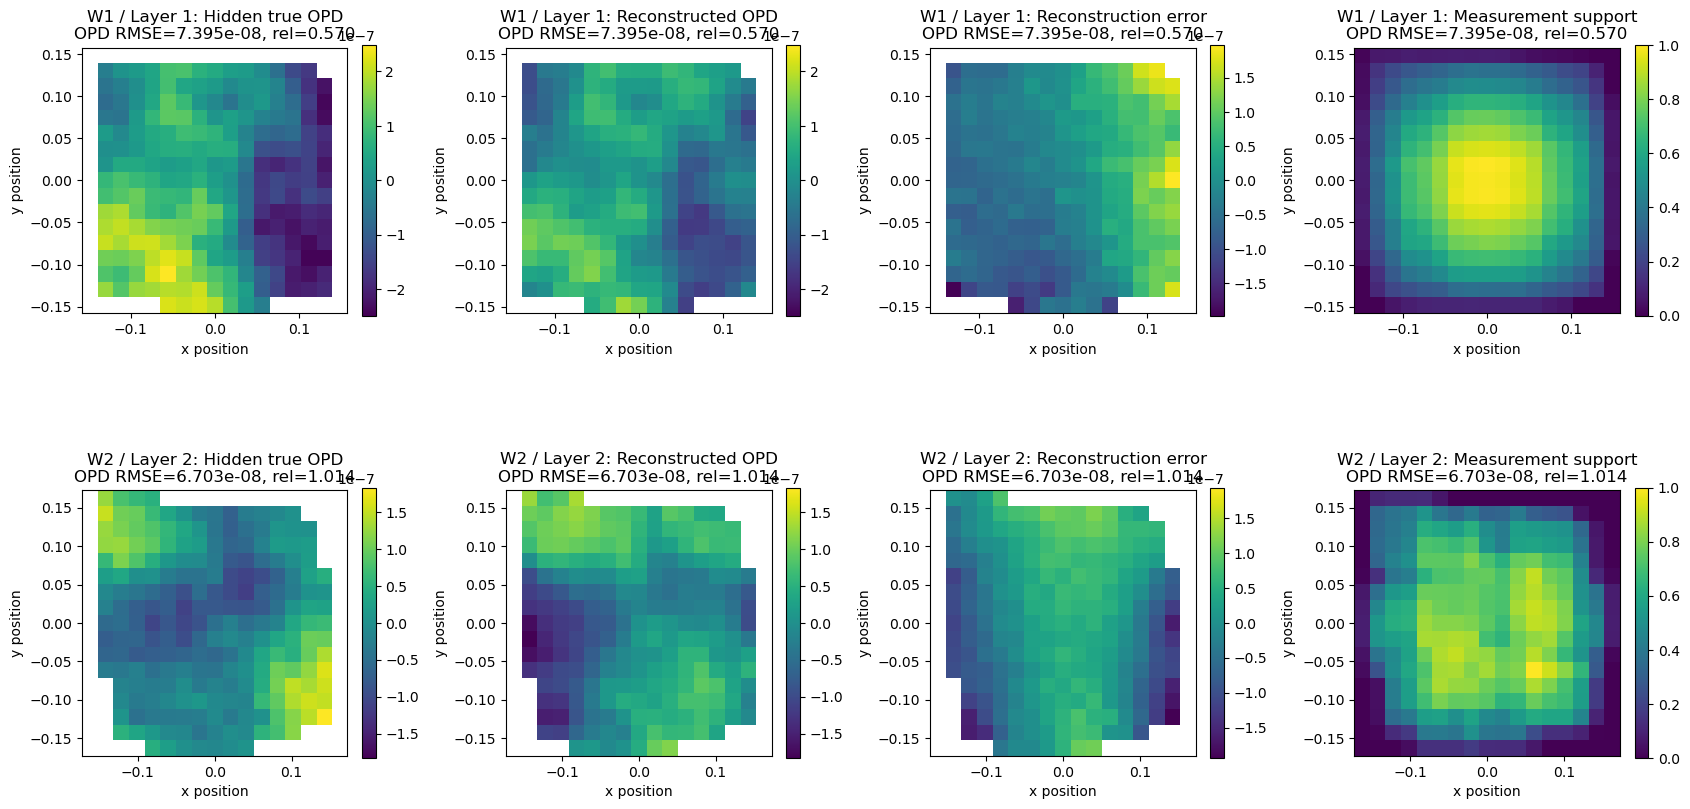

In [63]:
# Plot reconstructed 2D OPD maps.
fig, axes = plt.subplots(
    len(turbulent_layers),
    4,
    figsize=(17, 4.5 * len(turbulent_layers)),
)

if len(turbulent_layers) == 1:
    axes = axes[None, :]

for layer_id, layer in enumerate(turbulent_layers):
    x_grid = layer["estimation_x_grid"]
    y_grid = layer["estimation_y_grid"]
    extent_est = [x_grid[0], x_grid[-1], y_grid[0], y_grid[-1]]
    support_mask = layer["support_mask"]

    true_W = np.where(support_mask, layer["W_true_compare"], np.nan)
    est_W = np.where(support_mask, layer["W_est"], np.nan)
    error_W = np.where(support_mask, layer["W_error"], np.nan)
    support_strength = layer["support_strength"]
    vmax = max(np.nanmax(np.abs(true_W)), np.nanmax(np.abs(est_W)), 1e-12)

    panels = [
        (true_W, "Hidden true OPD", vmax),
        (est_W, "Reconstructed OPD", vmax),
        (error_W, "Reconstruction error", max(np.nanmax(np.abs(error_W)), 1e-12)),
        (support_strength, "Measurement support", 1.0),
    ]

    for col_id, (panel, title, vmax_panel) in enumerate(panels):
        ax = axes[layer_id, col_id]
        if title == "Measurement support":
            im = ax.imshow(panel, origin="lower", extent=extent_est, aspect="equal", vmin=0, vmax=1)
        else:
            im = ax.imshow(
                panel, origin="lower", extent=extent_est, aspect="equal",
                vmin=-vmax_panel,
                vmax=vmax_panel,
            )
        ax.set_title(
            f"{layer['name']}: {title}\n"
            f"OPD RMSE={layer['wavefront_rmse']:.3e}, "
            f"rel={layer['relative_wavefront_rmse']:.3f}"
        )
        ax.set_xlabel("x position")
        ax.set_ylabel("y position")
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

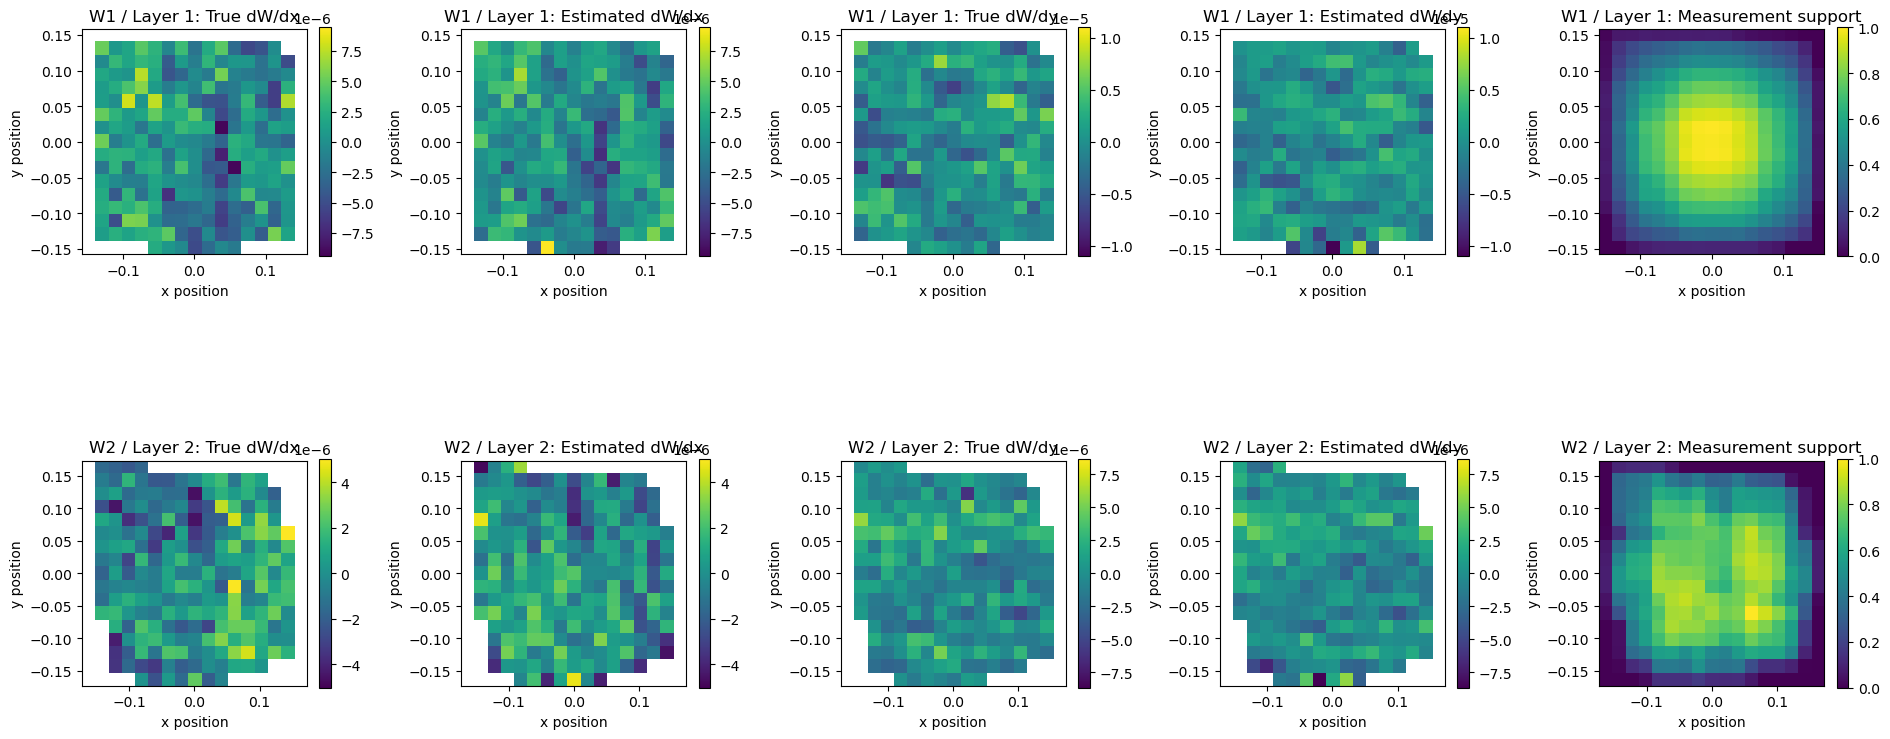

In [64]:
# Plot estimated slope fields against the hidden true slope fields.
fig, axes = plt.subplots(
    len(turbulent_layers),
    5,
    figsize=(19, 4.5 * len(turbulent_layers)),
)

if len(turbulent_layers) == 1:
    axes = axes[None, :]

for layer_id, layer in enumerate(turbulent_layers):
    x_grid = layer["estimation_x_grid"]
    y_grid = layer["estimation_y_grid"]
    extent_est = [x_grid[0], x_grid[-1], y_grid[0], y_grid[-1]]
    support_mask = layer["support_mask"]

    true_x = masked_zero_mean(layer["true_tilt_x_on_grid"], support_mask)
    est_x = masked_zero_mean(layer["estimated_tilt_x"], support_mask)
    true_y = masked_zero_mean(layer["true_tilt_y_on_grid"], support_mask)
    est_y = masked_zero_mean(layer["estimated_tilt_y"], support_mask)

    true_x = np.where(support_mask, true_x, np.nan)
    est_x = np.where(support_mask, est_x, np.nan)
    true_y = np.where(support_mask, true_y, np.nan)
    est_y = np.where(support_mask, est_y, np.nan)

    vmax_x = max(np.nanmax(np.abs(true_x)), np.nanmax(np.abs(est_x)), 1e-12)
    vmax_y = max(np.nanmax(np.abs(true_y)), np.nanmax(np.abs(est_y)), 1e-12)
    panels = [
        (true_x, "True dW/dx", vmax_x),
        (est_x, "Estimated dW/dx", vmax_x),
        (true_y, "True dW/dy", vmax_y),
        (est_y, "Estimated dW/dy", vmax_y),
        (layer["support_strength"], "Measurement support", 1.0),
    ]

    for col_id, (panel, title, vmax) in enumerate(panels):
        ax = axes[layer_id, col_id]
        if title == "Measurement support":
            im = ax.imshow(panel, origin="lower", extent=extent_est, aspect="equal", vmin=0, vmax=1)
        else:
            im = ax.imshow(
                panel, origin="lower", extent=extent_est, aspect="equal",
                vmin=-vmax, vmax=vmax,
            )
        ax.set_title(f"{layer['name']}: {title}")
        ax.set_xlabel("x position")
        ax.set_ylabel("y position")
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## 8. Reconstruction Validation

Hidden truth is introduced only after reconstruction to evaluate:

- layer-wise slope correlation,
- layer-wise slope RMSE,
- OPD RMSE after piston removal,
- relative OPD RMSE,
- forward consistency of the reconstructed summed tilt.

> **Important interpretation:** a good forward fit and a good individual-layer reconstruction are different requirements. Always inspect both.


In [65]:
# Diagnostic 2: layer-wise validation metrics.

metric_labels = []
metric_corrs = []
metric_slope_rmses = []
metric_opd_rmses = []
metric_relative_opd_rmses = []

print("Diagnostic 2: layer-wise slope and OPD validation")
print("Layer / component        corr        slope_RMSE")

for layer in turbulent_layers:
    entries = [
        ("dW/dx", layer["tilt_x_corr"], layer["tilt_x_rmse"]),
        ("dW/dy", layer["tilt_y_corr"], layer["tilt_y_rmse"]),
    ]

    for component, corr_value, rmse_value in entries:
        label = f"{layer['name']} {component}"
        metric_labels.append(label)
        metric_corrs.append(corr_value)
        metric_slope_rmses.append(rmse_value)

        print(f"{label:20s}  {corr_value:8.3f}  {rmse_value:10.3e}")

print()
print("Layer OPD metrics")
print("Layer                 OPD_RMSE     relative_OPD_RMSE")

for layer in turbulent_layers:
    metric_opd_rmses.append(layer["wavefront_rmse"])
    metric_relative_opd_rmses.append(layer["relative_wavefront_rmse"])

    print(
        f"{layer['name']:20s}  "
        f"{layer['wavefront_rmse']:10.3e}  "
        f"{layer['relative_wavefront_rmse']:10.3f}"
    )


Diagnostic 2: layer-wise slope and OPD validation
Layer / component        corr        slope_RMSE
W1 / Layer 1 dW/dx       0.687   2.341e-06
W1 / Layer 1 dW/dy       0.633   2.281e-06
W2 / Layer 2 dW/dx       0.366   2.023e-06
W2 / Layer 2 dW/dy       0.665   1.618e-06

Layer OPD metrics
Layer                 OPD_RMSE     relative_OPD_RMSE
W1 / Layer 1           7.395e-08       0.570
W2 / Layer 2           6.703e-08       1.014


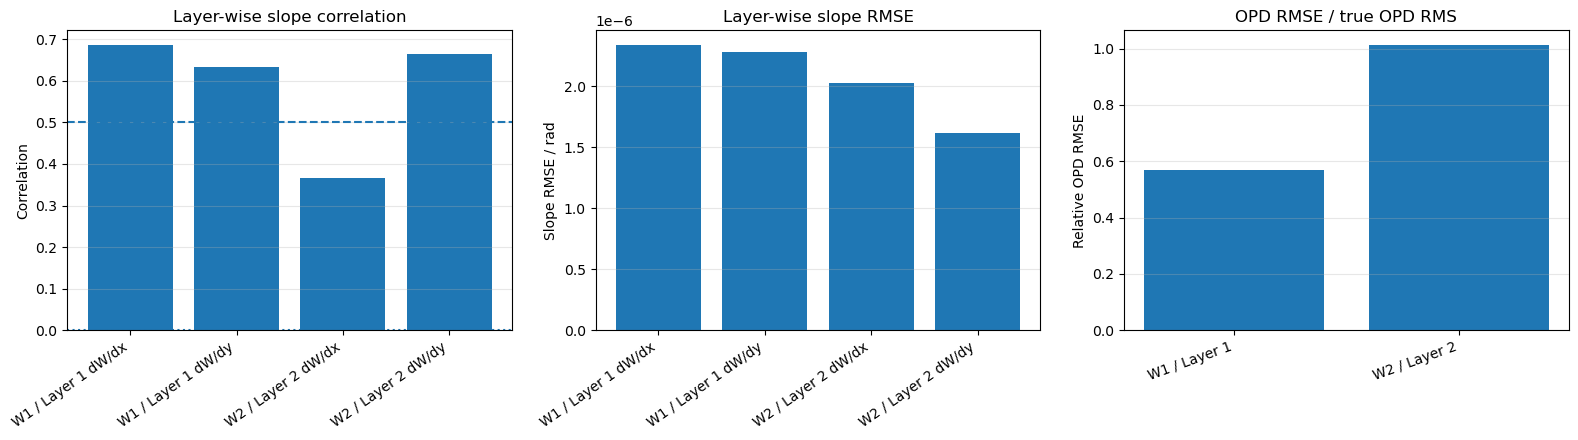

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x_positions = np.arange(len(metric_labels))

axes[0].bar(x_positions, metric_corrs)
axes[0].axhline(0.5, linestyle="--")
axes[0].axhline(0.0, linestyle=":")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(metric_labels, rotation=35, ha="right")
axes[0].set_ylabel("Correlation")
axes[0].set_title("Layer-wise slope correlation")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x_positions, metric_slope_rmses)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(metric_labels, rotation=35, ha="right")
axes[1].set_ylabel("Slope RMSE / rad")
axes[1].set_title("Layer-wise slope RMSE")
axes[1].grid(axis="y", alpha=0.3)

layer_names = [layer["name"] for layer in turbulent_layers]
x_layer = np.arange(len(layer_names))

axes[2].bar(x_layer, metric_relative_opd_rmses)
axes[2].set_xticks(x_layer)
axes[2].set_xticklabels(layer_names, rotation=20, ha="right")
axes[2].set_ylabel("Relative OPD RMSE")
axes[2].set_title("OPD RMSE / true OPD RMS")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [67]:
# Forward check: reconstructed layers should reproduce the measured relative total tilt.
model_tilt_x, model_tilt_y = forward_check_total_tilt(A, solution_x, solution_y)

forward_corr_x = safe_corrcoef(b_x, model_tilt_x)
forward_corr_y = safe_corrcoef(b_y, model_tilt_y)

measurement_fit_rmse_x = np.sqrt(np.mean((model_tilt_x - b_x)**2))
measurement_fit_rmse_y = np.sqrt(np.mean((model_tilt_y - b_y)**2))

print("Forward check after tomography")
print(f"x measured-vs-model corr: {forward_corr_x:.3f}")
print(f"y measured-vs-model corr: {forward_corr_y:.3f}")
print(f"fit_RMSE_x: {measurement_fit_rmse_x:.3e} rad")
print(f"fit_RMSE_y: {measurement_fit_rmse_y:.3e} rad")


Forward check after tomography
x measured-vs-model corr: 0.713
y measured-vs-model corr: 0.661
fit_RMSE_x: 2.247e-06 rad
fit_RMSE_y: 2.263e-06 rad


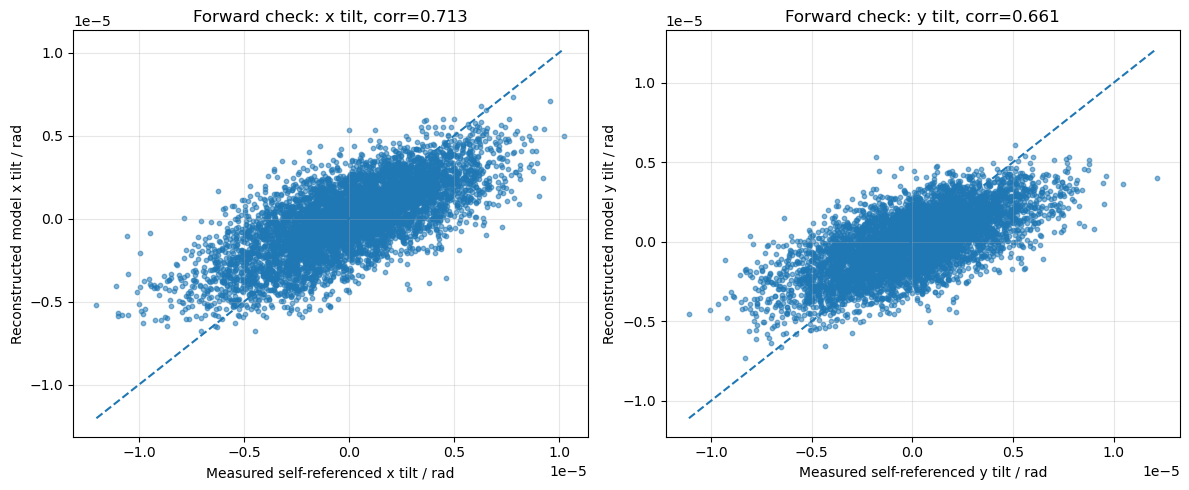

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(b_x, model_tilt_x, s=10, alpha=0.55)
line_min = min(b_x.min(), model_tilt_x.min())
line_max = max(b_x.max(), model_tilt_x.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "--")
axes[0].set_xlabel("Measured self-referenced x tilt / rad")
axes[0].set_ylabel("Reconstructed model x tilt / rad")
axes[0].set_title(f"Forward check: x tilt, corr={forward_corr_x:.3f}")
axes[0].grid(alpha=0.3)

axes[1].scatter(b_y, model_tilt_y, s=10, alpha=0.55)
line_min = min(b_y.min(), model_tilt_y.min())
line_max = max(b_y.max(), model_tilt_y.max())
axes[1].plot([line_min, line_max], [line_min, line_max], "--")
axes[1].set_xlabel("Measured self-referenced y tilt / rad")
axes[1].set_ylabel("Reconstructed model y tilt / rad")
axes[1].set_title(f"Forward check: y tilt, corr={forward_corr_y:.3f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Pupil-Plane AO Propagation and Strehl Ratio

For one representative source direction, the hidden and reconstructed layer OPDs are projected onto the pupil.

The complex pupil is

$$U_p(x,y)=P(x,y)\exp\left(i\frac{2\pi W(x,y)}{\lambda}\right).$$

The estimated AO correction leaves the residual

$$W_{\mathrm{res}}=W_{\mathrm{true}}-W_{\mathrm{est}}.$$

The focal-plane PSF is then obtained from the Fourier transform of the complex pupil, and the Strehl ratio compares its peak with the diffraction-limited peak.

> **Key update:** the reconstruction is now connected to an actual optical consequence rather than judged only by OPD plots.

> **Main difficulty:** individual reconstructed layers can look imperfect while still producing a useful correction for one source direction. Strehl depends on the **effective residual pupil OPD**, so it must be interpreted together with layer-wise reconstruction metrics.


In [69]:
def remove_best_fit_plane_from_masked(W, X, Y, mask):
    """Remove best-fit piston + tip + tilt on a masked pupil region."""
    valid = mask & np.isfinite(W)
    if np.sum(valid) < 3:
        return W - np.nanmean(W), np.zeros_like(W), np.array([np.nan, np.nan, np.nan])

    M = np.column_stack([
        np.ones(np.sum(valid)),
        X[valid],
        Y[valid],
    ])
    coeff, *_ = np.linalg.lstsq(M, W[valid], rcond=None)
    plane = coeff[0] + coeff[1] * X + coeff[2] * Y
    return W - plane, plane, coeff


def make_pupil_grid(aperture_radius, n_pupil=192):
    """Build a square grid containing the circular pupil."""
    pupil_axis = np.linspace(-aperture_radius, aperture_radius, n_pupil)
    X_pupil, Y_pupil = np.meshgrid(pupil_axis, pupil_axis, indexing="xy")
    pupil_mask = X_pupil**2 + Y_pupil**2 <= aperture_radius**2
    return pupil_axis, X_pupil, Y_pupil, pupil_mask


def sample_true_total_opd_over_pupil(X_pupil, Y_pupil, x_source, y_source):
    """Sample the hidden true two-layer OPD over the pupil for one source direction."""
    W_total = np.zeros_like(X_pupil, dtype=float)

    for layer in turbulent_layers:
        x_hit, y_hit = xy_at_layer(
            x_source,
            y_source,
            X_pupil,
            Y_pupil,
            layer["z"],
        )
        W_total += layer_opd(layer, x_hit, y_hit)

    return W_total


def sample_estimated_total_opd_over_pupil(X_pupil, Y_pupil, x_source, y_source):
    """Sample the reconstructed two-layer OPD over the pupil for one source direction."""
    W_total = np.zeros_like(X_pupil, dtype=float)
    valid_estimation_support = np.ones_like(X_pupil, dtype=bool)

    for layer in turbulent_layers:
        x_hit, y_hit = xy_at_layer(
            x_source,
            y_source,
            X_pupil,
            Y_pupil,
            layer["z"],
        )

        x_grid = layer["estimation_x_grid"]
        y_grid = layer["estimation_y_grid"]

        inside_grid = (
            (x_hit >= x_grid[0]) & (x_hit <= x_grid[-1]) &
            (y_hit >= y_grid[0]) & (y_hit <= y_grid[-1])
        )

        support_value = interp2_uniform(
            x_grid,
            y_grid,
            layer["support_strength"],
            x_hit,
            y_hit,
        )
        valid_estimation_support &= inside_grid & (support_value >= support_threshold)

        W_total += interp2_uniform(
            x_grid,
            y_grid,
            layer["W_est"],
            x_hit,
            y_hit,
        )

    return W_total, valid_estimation_support


def psf_from_pupil_opd(W_opd, pupil_mask, wavelength, pad_factor=4):
    """Generate a normalised focal-plane PSF from pupil OPD."""
    n = W_opd.shape[0]
    n_pad = int(pad_factor * n)
    start = (n_pad - n) // 2

    complex_pupil = pupil_mask.astype(float) * np.exp(1j * 2 * np.pi * W_opd / wavelength)

    padded = np.zeros((n_pad, n_pad), dtype=complex)
    padded[start:start + n, start:start + n] = complex_pupil

    field = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(padded)))
    psf = np.abs(field)**2
    psf = psf / np.sum(psf)
    return psf


def log_psf_for_display(psf, floor=1e-8):
    """Display helper for high-dynamic-range PSF images."""
    return np.log10(psf / np.max(psf) + floor)


def masked_rms(W, mask):
    values = W[mask]
    return np.sqrt(np.mean(values**2))

In [70]:
# Select a representative source close to the optical axis.
source_positions = np.array([[info["x_source"], info["y_source"]] for info in source_info])
selected_pupil_source_index = int(np.argmin(np.sum(source_positions**2, axis=1)))
selected_source = source_info[selected_pupil_source_index]

x_source_pupil = selected_source["x_source"]
y_source_pupil = selected_source["y_source"]
theta_x_pupil = selected_source["theta_x"]
theta_y_pupil = selected_source["theta_y"]

pupil_axis, X_pupil, Y_pupil, pupil_mask = make_pupil_grid(
    aperture_radius=aperture_radius,
    n_pupil=192,
)

W_true_pupil = sample_true_total_opd_over_pupil(
    X_pupil, Y_pupil, x_source_pupil, y_source_pupil,
)
W_est_pupil, valid_estimation_support = sample_estimated_total_opd_over_pupil(
    X_pupil, Y_pupil, x_source_pupil, y_source_pupil,
)

pupil_valid_mask = pupil_mask & valid_estimation_support

# Remove piston + global image motion before comparing the reconstructable spatial OPD.
W_true_pupil_no_plane, true_plane, true_plane_coeff = remove_best_fit_plane_from_masked(
    W_true_pupil, X_pupil, Y_pupil, pupil_valid_mask,
)
W_est_pupil_no_plane, est_plane, est_plane_coeff = remove_best_fit_plane_from_masked(
    W_est_pupil, X_pupil, Y_pupil, pupil_valid_mask,
)
W_residual_pupil = W_true_pupil_no_plane - W_est_pupil_no_plane

W_true_pupil_plot = np.where(pupil_valid_mask, W_true_pupil_no_plane, np.nan)
W_est_pupil_plot = np.where(pupil_valid_mask, W_est_pupil_no_plane, np.nan)
W_residual_pupil_plot = np.where(pupil_valid_mask, W_residual_pupil, np.nan)

wavelength_model = wavelength_observation
true_opd_rms_pupil = masked_rms(W_true_pupil_no_plane, pupil_valid_mask)
est_opd_rms_pupil = masked_rms(W_est_pupil_no_plane, pupil_valid_mask)
residual_opd_rms_pupil = masked_rms(W_residual_pupil, pupil_valid_mask)
relative_residual_opd_rms_pupil = residual_opd_rms_pupil / (true_opd_rms_pupil + 1e-30)

W_true_for_psf = np.where(pupil_valid_mask, W_true_pupil_no_plane, 0.0)
W_residual_for_psf = np.where(pupil_valid_mask, W_residual_pupil, 0.0)
pupil_mask_for_psf = pupil_valid_mask

psf_diffraction_limited = psf_from_pupil_opd(
    np.zeros_like(W_true_for_psf), pupil_mask_for_psf, wavelength_model, pad_factor=4,
)
psf_true_turbulent = psf_from_pupil_opd(
    W_true_for_psf, pupil_mask_for_psf, wavelength_model, pad_factor=4,
)
psf_corrected_estimated = psf_from_pupil_opd(
    W_residual_for_psf, pupil_mask_for_psf, wavelength_model, pad_factor=4,
)

strehl_turbulent = psf_true_turbulent.max() / psf_diffraction_limited.max()
strehl_corrected = psf_corrected_estimated.max() / psf_diffraction_limited.max()

marechal_true = np.exp(-(2 * np.pi * true_opd_rms_pupil / wavelength_model)**2)
marechal_residual = np.exp(-(2 * np.pi * residual_opd_rms_pupil / wavelength_model)**2)

print("Pupil-plane OPD propagation diagnostic — typical atmosphere")
print(f"Selected source id: {selected_source['source_id']}")
print(f"Representative source position: x={x_source_pupil:.3f}, y={y_source_pupil:.3f}")
print(f"Usable pupil support: {100 * np.mean(pupil_valid_mask[pupil_mask]):.1f}%")
print(f"Observation wavelength: {wavelength_model * 1e9:.0f} nm")
print(f"Seeing / total r0: {seeing_arcsec:.2f} arcsec / {r0_total:.3f} m")
print(f"Aperture diameter / r0: {2 * aperture_radius / r0_total:.2f}")
print(f"True pupil OPD RMS:      {true_opd_rms_pupil * 1e9:.1f} nm ({true_opd_rms_pupil / wavelength_model:.3f} waves)")
print(f"Estimated pupil OPD RMS: {est_opd_rms_pupil * 1e9:.1f} nm ({est_opd_rms_pupil / wavelength_model:.3f} waves)")
print(f"Residual pupil OPD RMS:  {residual_opd_rms_pupil * 1e9:.1f} nm ({residual_opd_rms_pupil / wavelength_model:.3f} waves)")
print(f"Residual / true OPD RMS: {relative_residual_opd_rms_pupil:.3f}")
print(f"Turbulent Strehl ratio:  {strehl_turbulent:.3f}")
print(f"Corrected Strehl ratio:  {strehl_corrected:.3f}")
print(f"Marechal estimates (true / residual): {marechal_true:.3f} / {marechal_residual:.3f}")

Pupil-plane OPD propagation diagnostic — typical atmosphere
Selected source id: 14
Representative source position: x=-0.034, y=-0.049
Usable pupil support: 100.0%
Observation wavelength: 500 nm
Seeing / total r0: 1.00 arcsec / 0.101 m
Aperture diameter / r0: 3.91
True pupil OPD RMS:      69.8 nm (0.140 waves)
Estimated pupil OPD RMS: 58.5 nm (0.117 waves)
Residual pupil OPD RMS:  19.4 nm (0.039 waves)
Residual / true OPD RMS: 0.277
Turbulent Strehl ratio:  0.448
Corrected Strehl ratio:  0.942
Marechal estimates (true / residual): 0.463 / 0.942


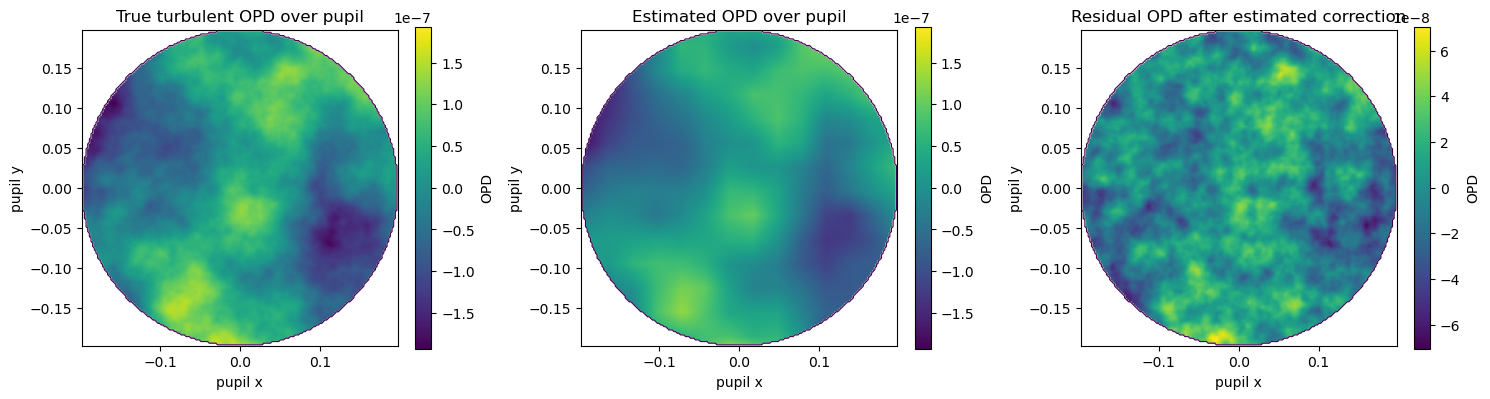

In [71]:

# Plot pupil-plane OPD maps before and after correction.
extent_pupil = [pupil_axis[0], pupil_axis[-1], pupil_axis[0], pupil_axis[-1]]

opd_vmax = max(
    np.nanmax(np.abs(W_true_pupil_plot)),
    np.nanmax(np.abs(W_est_pupil_plot)),
    1e-12,
)
residual_vmax = max(np.nanmax(np.abs(W_residual_pupil_plot)), 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

panels = [
    (W_true_pupil_plot, "True turbulent OPD over pupil", opd_vmax),
    (W_est_pupil_plot, "Estimated OPD over pupil", opd_vmax),
    (W_residual_pupil_plot, "Residual OPD after estimated correction", residual_vmax),
]

for ax, (panel, title, vmax) in zip(axes, panels):
    im = ax.imshow(
        panel,
        origin="lower",
        extent=extent_pupil,
        aspect="equal",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.contour(X_pupil, Y_pupil, pupil_valid_mask.astype(float), levels=[0.5], linewidths=0.8)
    ax.set_title(title)
    ax.set_xlabel("pupil x")
    ax.set_ylabel("pupil y")
    plt.colorbar(im, ax=ax, fraction=0.046, label="OPD")

plt.tight_layout()
plt.show()


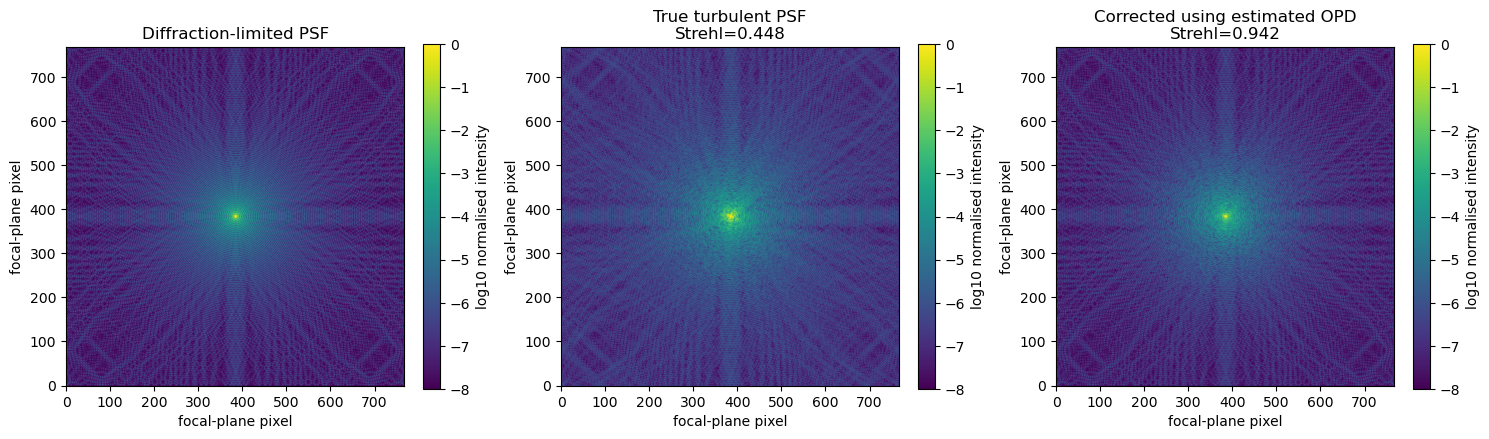

In [72]:

# Plot focal-plane PSFs at the physical 500 nm observation wavelength.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

psf_panels = [
    (psf_diffraction_limited, "Diffraction-limited PSF"),
    (psf_true_turbulent, f"True turbulent PSF\nStrehl={strehl_turbulent:.3f}"),
    (psf_corrected_estimated, f"Corrected using estimated OPD\nStrehl={strehl_corrected:.3f}"),
]

for ax, (psf, title) in zip(axes, psf_panels):
    im = ax.imshow(
        log_psf_for_display(psf, floor=1e-8),
        origin="lower",
        aspect="equal",
        vmin=-8,
        vmax=0,
    )
    ax.set_title(title)
    ax.set_xlabel("focal-plane pixel")
    ax.set_ylabel("focal-plane pixel")
    plt.colorbar(im, ax=ax, fraction=0.046, label="log10 normalised intensity")

plt.tight_layout()
plt.show()


### 9.1 Reproducibility Check

The default run represents approximately **1 arcsec seeing at 500 nm** with a roughly **0.40 m pupil**.

After changing seeing, wavelength, source geometry, lenslet sampling, or regularisation, re-run the notebook from the beginning and compare:

- NCC relative-tilt accuracy,
- layer-wise slope and OPD metrics,
- forward residual,
- residual-to-true pupil OPD RMS,
- turbulent and corrected Strehl ratios.


### 9.2 How to Read the v2.5.3 Result

The purpose of the coarse-to-fine method is not to make the hidden Kolmogorov layers easier. It changes the inverse problem so that large-scale layer separation is established before the solver attempts to recover finer spatial detail.

A convincing result should satisfy three conditions at the same time:

1. The NCC stage accurately recovers source-wise relative tilt.
2. Both reconstructed layers show reasonable agreement with hidden truth.
3. The reconstructed layers reproduce the measured summed tilt and reduce the effective pupil residual.

If only condition 3 is satisfied, the solver may still be fitting the measurements with the wrong layer decomposition.


## 10. Limitations and Next Steps

This notebook is substantially more physical than the first toy model, but it is still a simulation.

### Current limitations

- The phase screens are static; no wind-driven frozen-flow evolution is included.
- The outer scale is not calibrated from site-specific atmospheric data.
- Scintillation and amplitude fluctuations are not modelled.
- The atmosphere is represented by only two thin layers.
- The estimator recovers source-wise relative tilt rather than absolute common-mode tilt.
- The microlens model is diffraction-based, but the full instrument is still idealised.
- Hidden truth remains available for final simulation validation.

### Key takeaways

- **Kolmogorov statistics** provide a physically motivated aberration model.
- **Self-referenced pairwise NCC** removes the unrealistic clean-reference dependency.
- **Source identity must be preserved** because parallax carries layer-depth information.
- **Coarse-to-fine regularisation** helps reduce layer cross-talk in an ill-conditioned inverse problem.
- **Forward fit is necessary but not sufficient** for validating tomography.
- **Residual pupil OPD and Strehl ratio** connect reconstruction quality to AO imaging performance.

This notebook is intended to serve as the core atmospheric WFS/tomography example in the repository before the project is transferred to microscopy and two-photon AO.
